# Spike coordination in simultaneously recorded neural pairs

Do two neurons recorded at the same time coordinate their spiking more during
**interactive-face** fixations than during non-interactive-face or object
fixations, and does that differ **within** a region versus **across** regions?

Everything rests on per-fixation spike trains. Cross-correlating
condition-averaged PSTHs would measure shared rate structure, not coordination,
so every cross-correlation is computed on one fixation's two 1 ms trains and
only then averaged. The trains are **unsmoothed** — smoothing before
cross-correlation blurs exactly the fine timing this analysis exists to measure.

## Linear correlation, everything inside ±500 ms

The correlation is **linear** (zero-padded transform) — the statistic
`scipy.signal.correlate` computes, and the one the behavioural
cross-correlations use. At lag L only the `N − |L|` genuinely overlapping bins
contribute, so no spike is ever paired with one a full window away.

Observed and both nulls all use the same 1000 bins of 1 ms spike counts spanning
−500 to +500 ms around fixation onset. Nothing outside that window enters any
computation: 95% of ±5 s surrounds contain at least one *other* analysed
fixation (median 5), so outside the window is not baseline.

Linear correlation tapers — fewer bins contribute as |lag| grows — but both
nulls carry the identical taper, so it cancels in every excess and z-score.

## Reading the two nulls

| null | destroys | keeps | an excess means |
|---|---|---|---|
| **trial shuffle** | trial-by-trial covariation | each unit's fixation-locked rate profile | the cells co-fluctuate across fixations |
| **circular shift** | fine temporal alignment | that fixation's spike count and slow envelope | coordination finer than the shift |

The shift null rotates a train within the window, which wraps. That is fine in a
null — destroying alignment is the point — and is exactly why it is not fine in
the observed statistic.

## Which number to compare

- **`z`** — excess in units of the null SD of the fixation-averaged statistic.
  Grows with `sqrt(n_fixations)`. Use for *is this coordinated at all*.
- **`effect`** — `z / sqrt(n_fixations)`, in single-fixation null units. Does not
  depend on trial count. **Use to compare conditions**, since interactive-face
  fixations outnumber non-interactive ones about five to one.

## How results are reported

Per **region** for within-region pairs and per **region pair** for cross-region
pairs, *before* any pooling. Pooling first would let one region with many pairs
carry a conclusion that does not hold in the others. Pooled tables follow as a
summary. Everything is run on all recorded pairs first, then repeated on pairs
where both units are FDR-selective.

In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.ephys.analysis import fixation_pair_spike_coordination as psc
from dal_monte_2022_analysis.ephys.plotting import fixation_pair_spike_coordination as viz
from dal_monte_2022_analysis.ephys.plotting import thesis_common as style

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
cfg = load_config(str(DATASET_CFG_PATH))

SUMMARY_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "summary"
FIGURE_DIR = build_analysis_output_dir(cfg, psc.DEFAULT_OUTPUT_SUBDIR) / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig_settings = viz.PairCoordinationPlotSettings(output_dir=FIGURE_DIR)

#: The excess is standardised in single-fixation null units so that it does not
#: scale with how many fixations a condition contains.  Interactive-face
#: fixations outnumber non-interactive-face ones roughly five to one, so a
#: z-based comparison would rank conditions largely by trial count.
EFFECT_METRIC = "trial_shuffle_mean_effect_pm10ms"

print("summary dir:", SUMMARY_DIR)
print("figure dir :", FIGURE_DIR)

summary dir: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary
figure dir : /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/figures


## 1. Build state

Per-session tables are built by a SLURM array over the 42 recording dates. This
reports what exists; it queues nothing unless `SUBMIT_JOBS = True`, in which
case it submits only the incomplete dates and waits.

In [2]:
settings = psc.build_pair_spike_coordination_settings_from_config(
    dataset_cfg_path=str(DATASET_CFG_PATH),
    coordination_cfg_path=str(repo_root / "configs" / "ephys_fixation_pair_spike_coordination.yaml"),
)

# Submission is opt-in. The array job costs real cluster time and a notebook
# cell is easy to re-run by accident, so leaving this False only *reports* what
# is missing and prints the sbatch line to run.
SUBMIT_JOBS = False
WAIT_FOR_JOBS = True

per_date = psc.ensure_pair_coordination_built(
    settings,
    submit=SUBMIT_JOBS,
    wait=WAIT_FOR_JOBS,
    sbatch_path=repo_root / psc.DEFAULT_SBATCH_PATH,
    repo_root=repo_root,
)
display(per_date)

dates: 42 total, 1 complete, 41 incomplete
sessions: 9 of 417 built (0.05 GB on disk)
incomplete dates: ['01022019', '01032019', '01042019', '01052019', '01062019', '01072019', '01082019', '01092019', '01102019', '01112019', '01132019', '01142019', '01152019', '01162018', '01172018', '01172019', '01192018', '01302018', '02022018', '02042018', '02052018', '02062018', '02072018', '02082018', '02092018', '08242018', '08272018', '08282018', '08292018', '08302018', '08312018', '09042018', '09272018', '09292018', '09302018', '10012018', '10022018', '10032018', '10042018', '10092018', '10102018']

submit=False, so nothing was queued. To build these, run:
    sbatch --array=0-17,19-41 /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis/hpc/ephys/run_fixation_pair_spike_coordination.sbatch
or call this again with submit=True.


,date,n_sessions,n_built,total_mb,complete
0,01022019,10,0,0.000000,False
1,01032019,10,0,0.000000,False
2,01042019,10,0,0.000000,False
3,01052019,10,0,0.000000,False
4,01062019,10,0,0.000000,False
5,01072019,10,0,0.000000,False
6,01082019,10,0,0.000000,False
7,01092019,10,0,0.000000,False
8,01102019,10,0,0.000000,False
9,01112019,10,0,0.000000,False


Aggregate the per-session tables into the summary files the rest of the notebook
reads. This touches every session file, so set `REBUILD_SUMMARIES = False` to
reuse what is on disk.

In [3]:
# Regenerate the summary tables from whatever is on disk. Skip if they are
# already current -- this reads every session file, so it is the slow step.
REBUILD_SUMMARIES = True

if REBUILD_SUMMARIES:
    _ = psc.run_summary_build(settings, metric=EFFECT_METRIC)
else:
    display(Markdown("_Using the summary tables already on disk._"))

summary tables written to /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs/ephys/psth/fixation_pair_spike_coordination/summary


## 2. What is in the analysis

In [4]:
pairs, lags_ms = psc.load_pair_coordination(str(DATASET_CFG_PATH))
print(f"pair-condition rows: {len(pairs):,}")
print(f"lag axis: {lags_ms.size} bins, {lags_ms.min():.0f} to {lags_ms.max():.0f} ms")

inventory = psc.build_pair_inventory(pairs)
display(inventory)

pair-condition rows: 4,677
lag axis: 501 bins, -250 to 250 ms


,scope,condition,n_pairs,n_pairs_both_selective,n_dates,n_sessions,median_n_fixations
0,cross_region,face_interactive,883,414,1,9,35.0
1,cross_region,face_non_interactive,666,326,1,8,19.0
2,cross_region,object,891,428,1,9,37.0
3,within_region,face_interactive,810,356,1,9,35.0
4,within_region,face_non_interactive,605,279,1,8,19.0
5,within_region,object,822,367,1,9,37.0


## 3. What the correlation and its nulls actually look like

Read this first. The black curve is the mean cross-correlation across pairs, in
coincidences per fixation; the two dashed curves are where each null sits on the
same axes. The excess is something you can see rather than something to take on
trust from a z-score. Bands are standard error across pairs.

The two nulls should **not** coincide. The trial-shuffle null keeps each unit's
fixation-locked rate profile, so it sits at the level shared rate structure
alone produces. The circular-shift null keeps each fixation's own spike count
but destroys alignment. Observed above both is coordination that neither
explains.

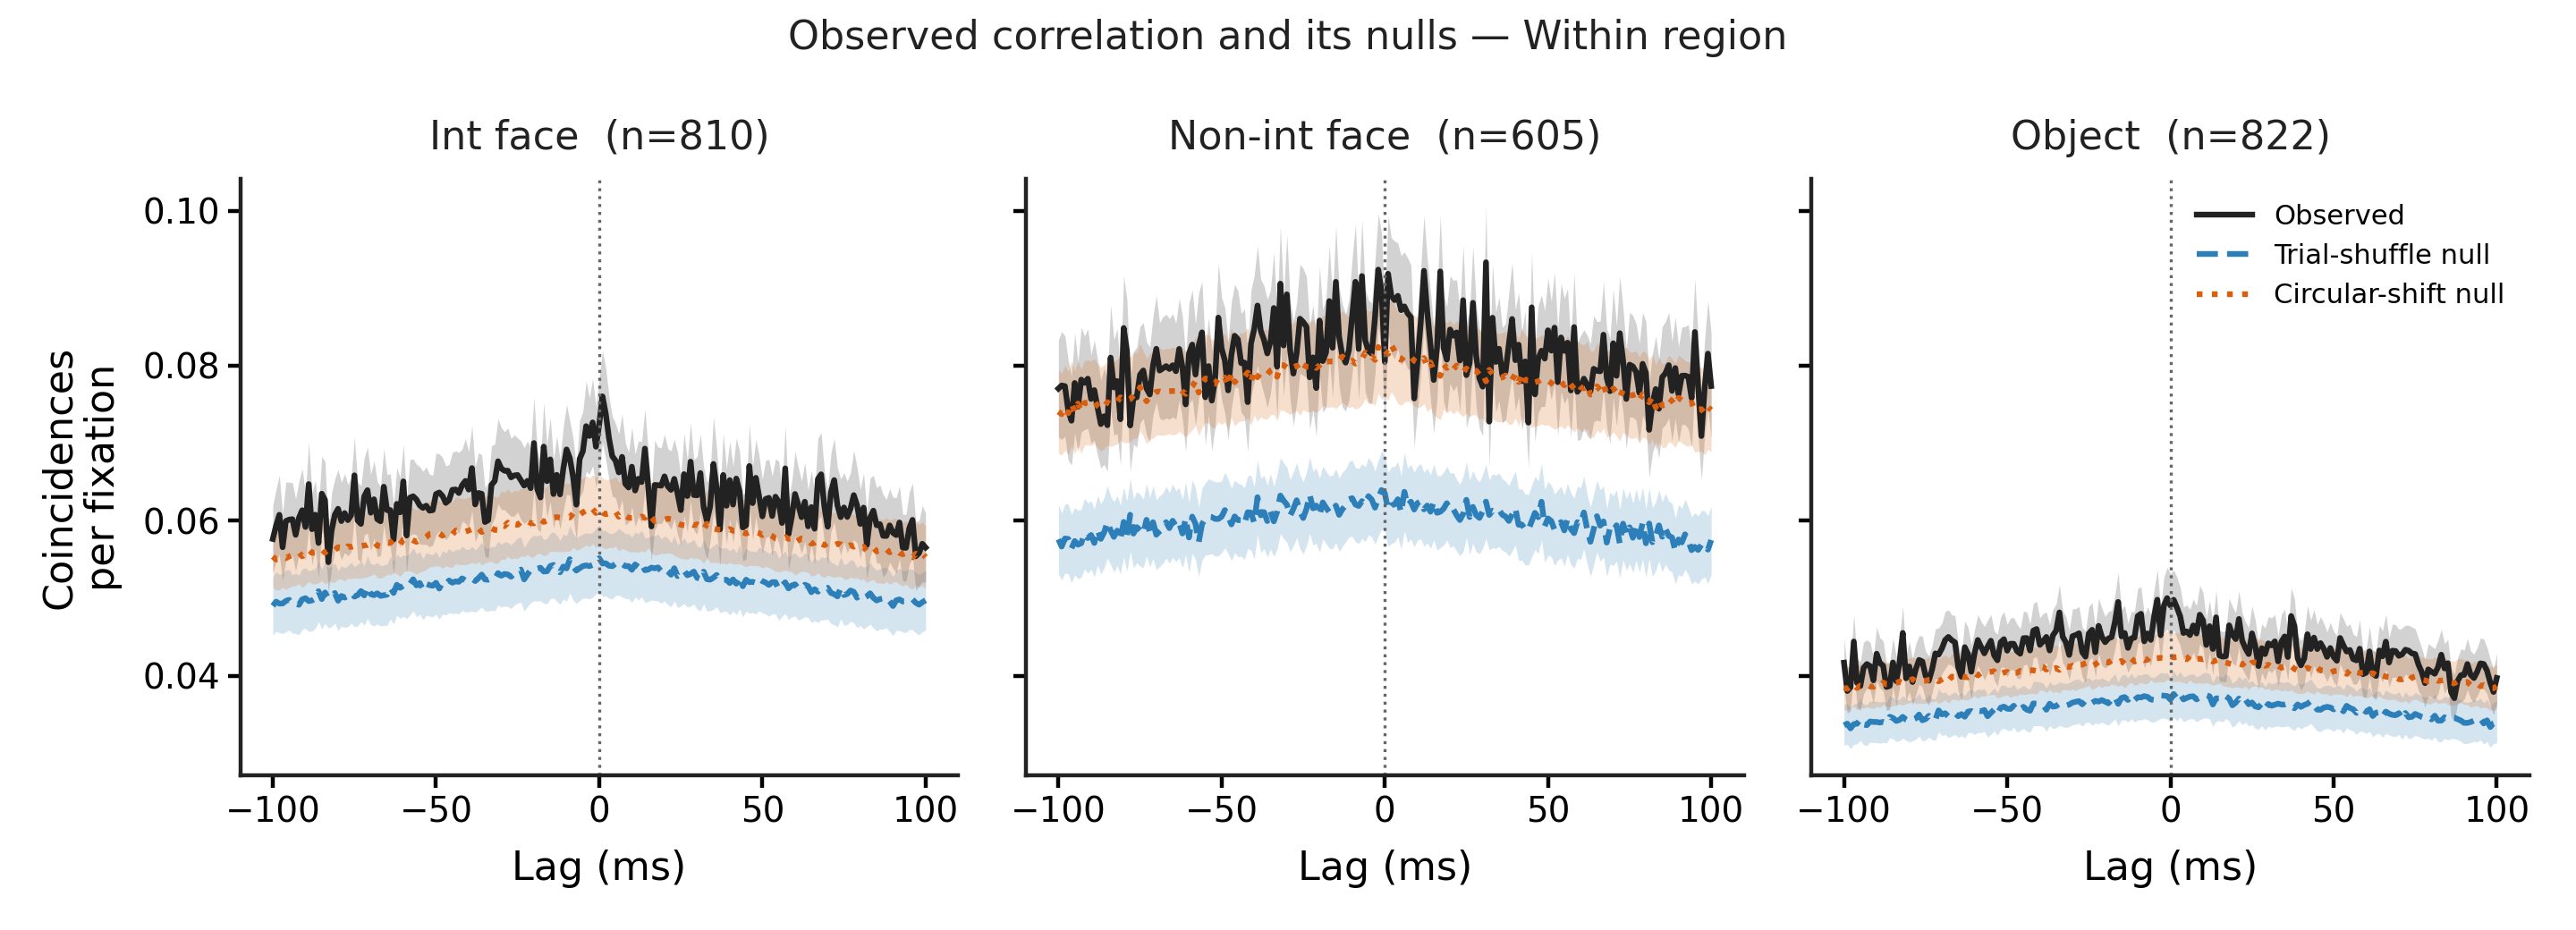

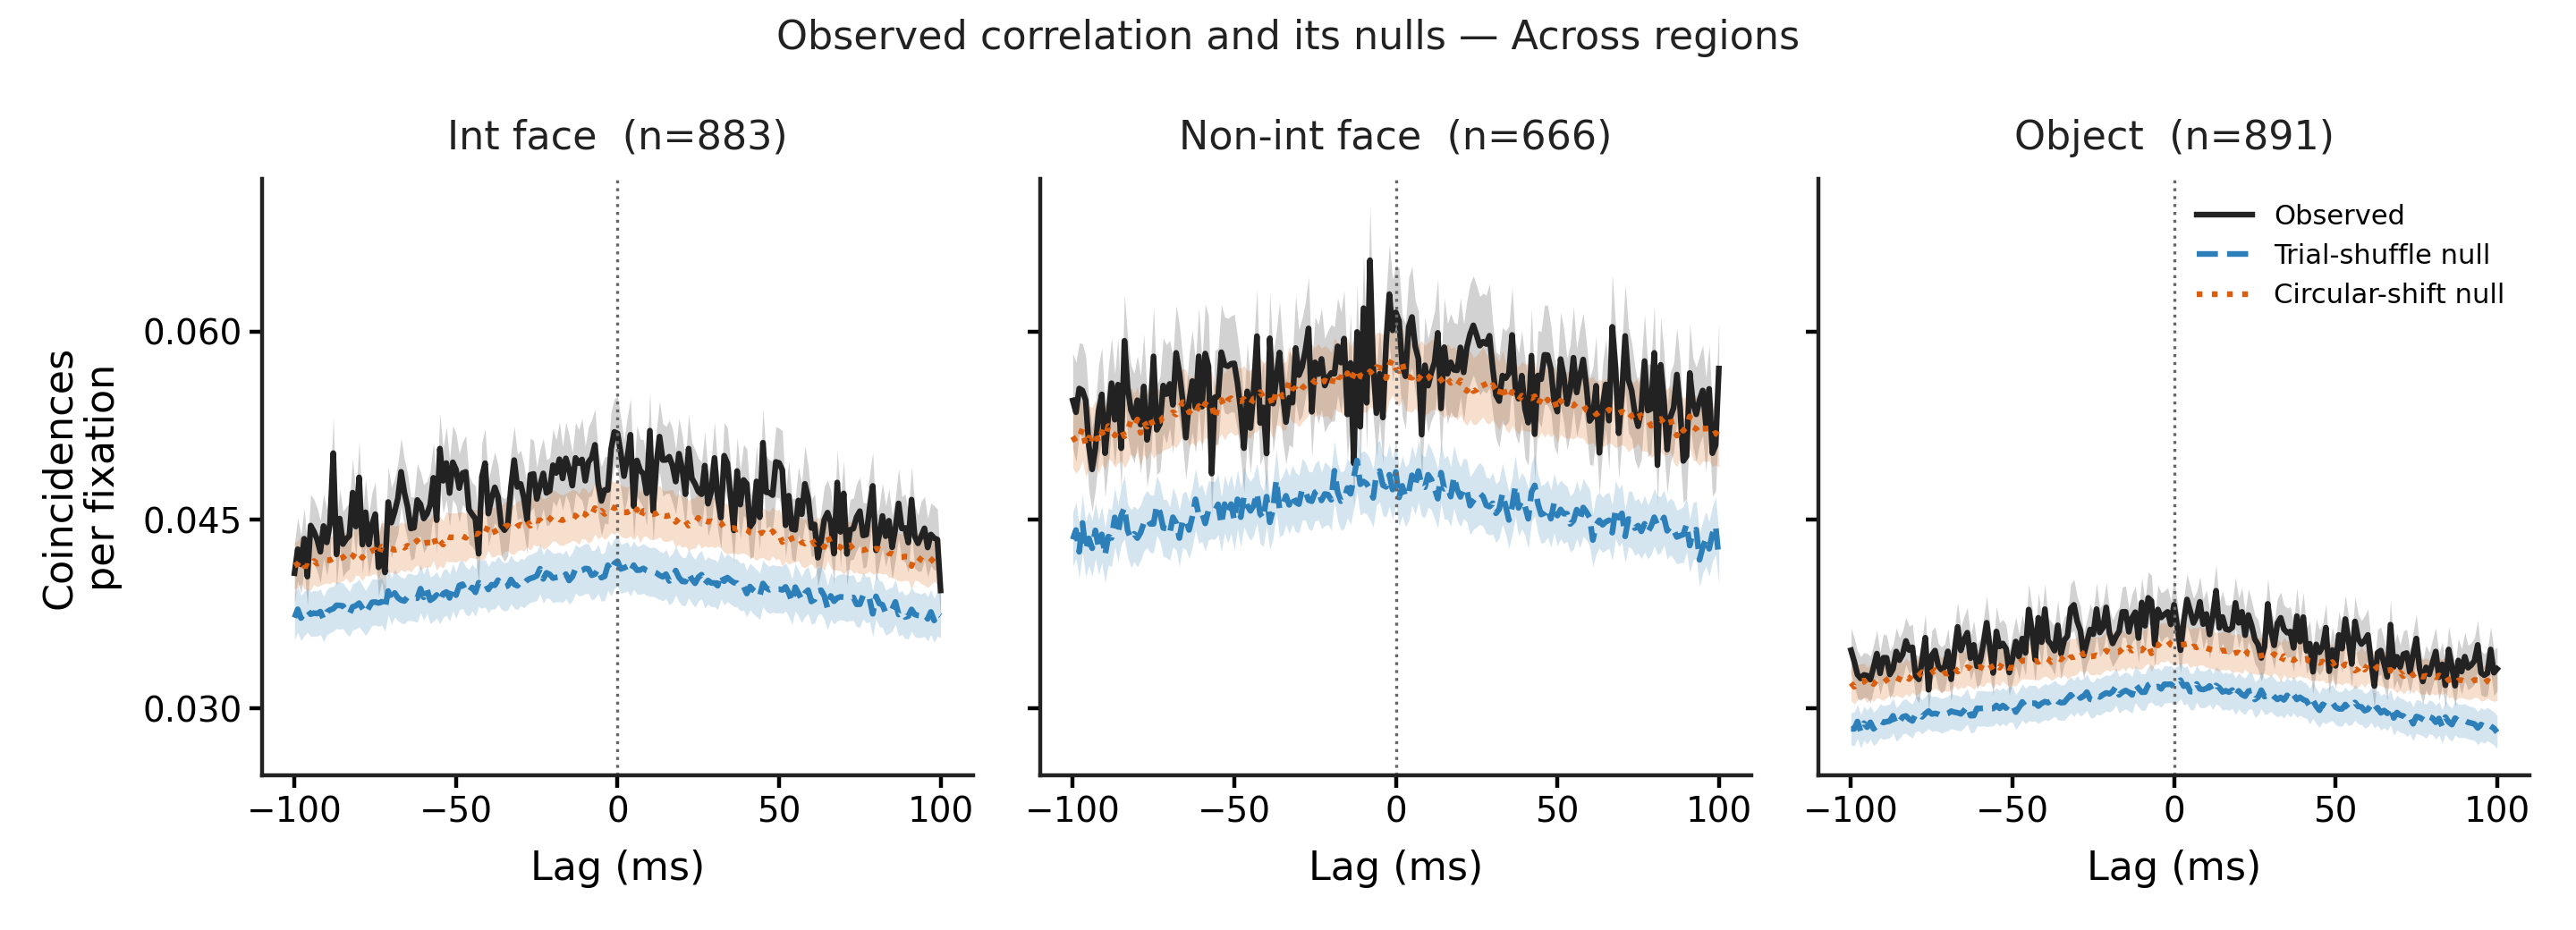

In [5]:
by_scope = pd.read_pickle(SUMMARY_DIR / "group_traces_by_scope.pkl")

for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_observed_and_nulls(by_scope, fig_settings, scope=scope)
    display(Image(filename=str(paths["png"])))

## 4. Excess over null, per region and per region pair

The same comparison as a standardised excess, resolved per region (within) and
per region pair (across), for both nulls. Zero is the null's own expectation.

Structure present against the trial-shuffle null but absent against the
circular-shift null is slow co-fluctuation rather than fine synchrony.

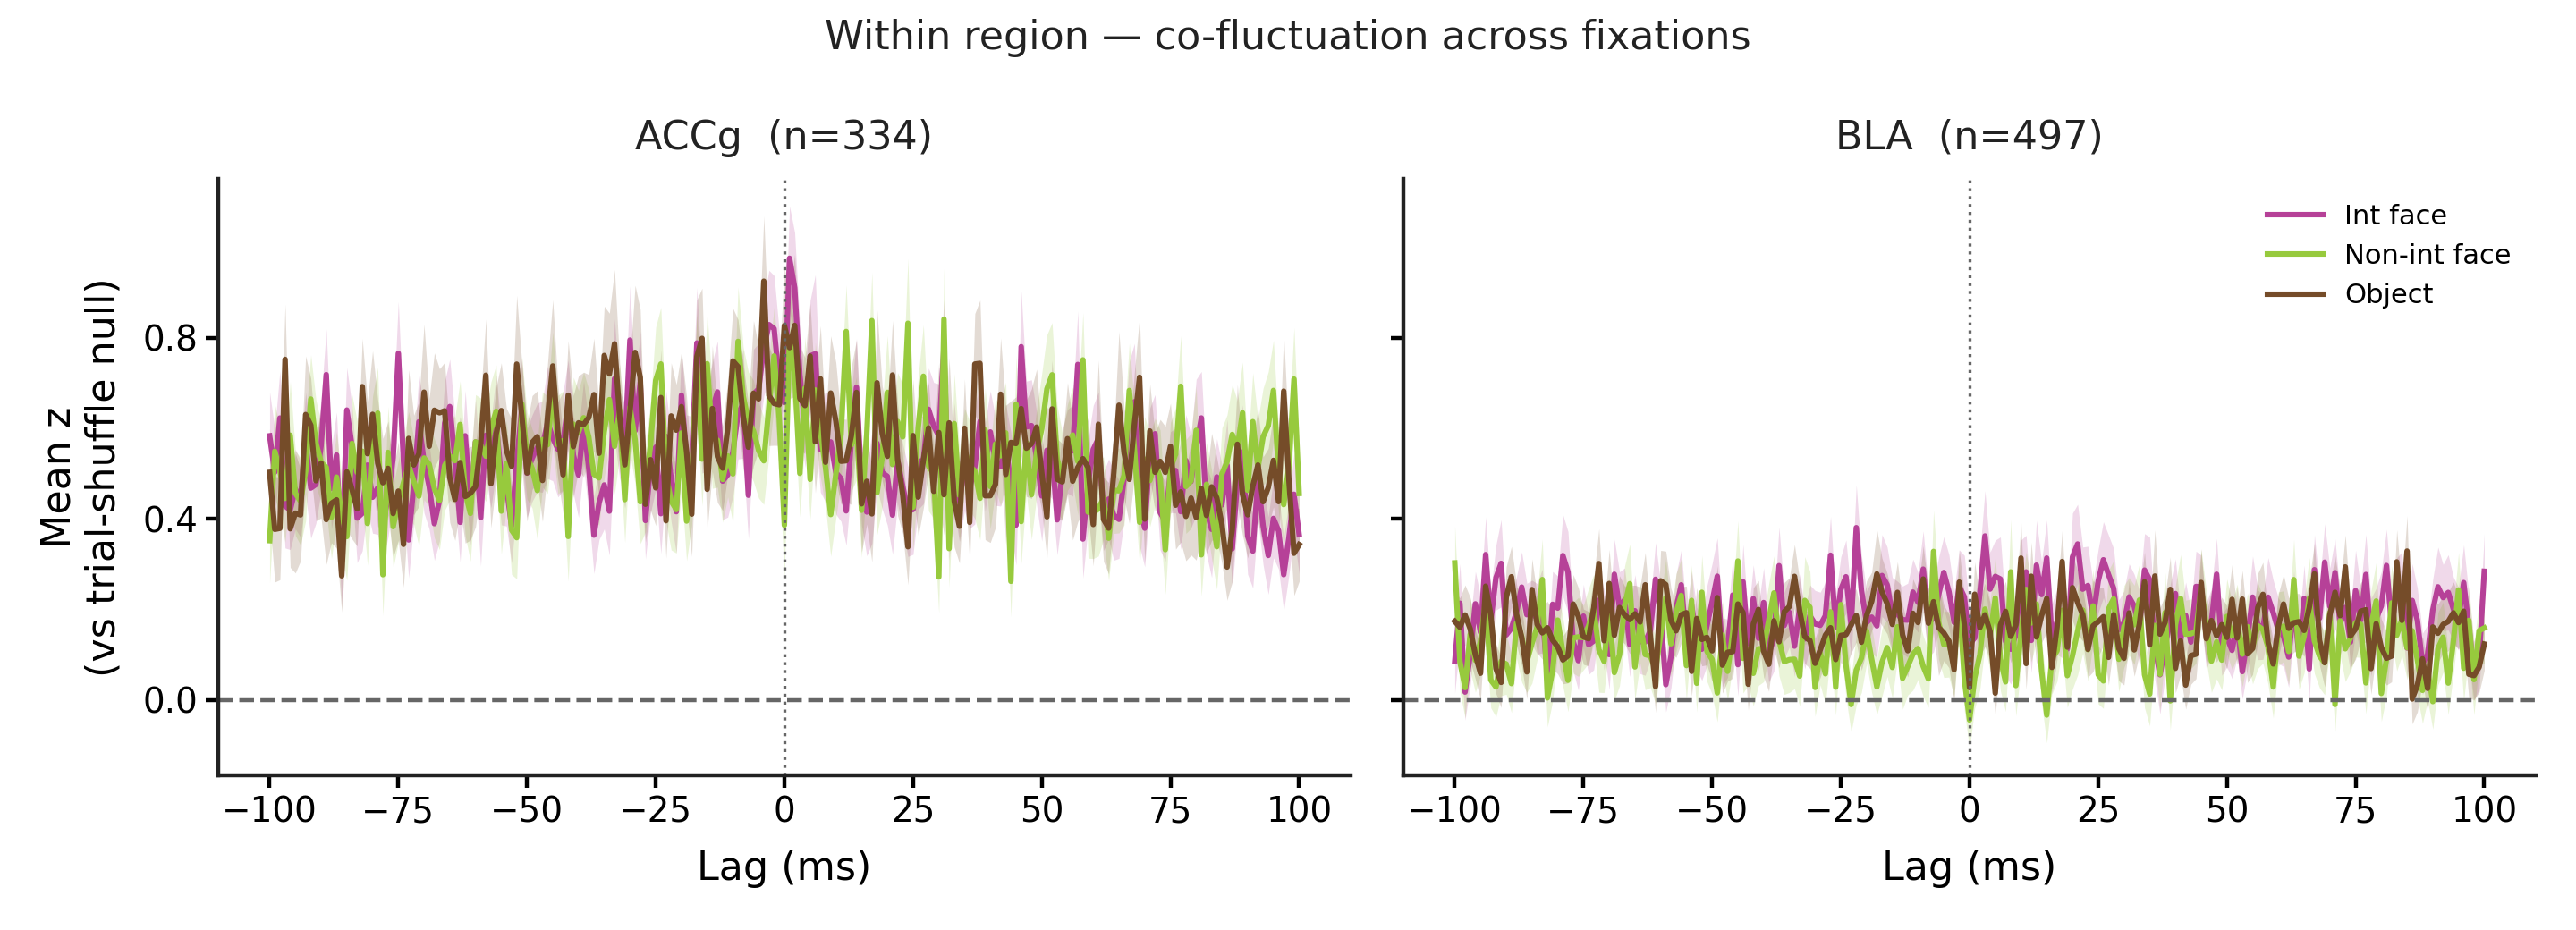

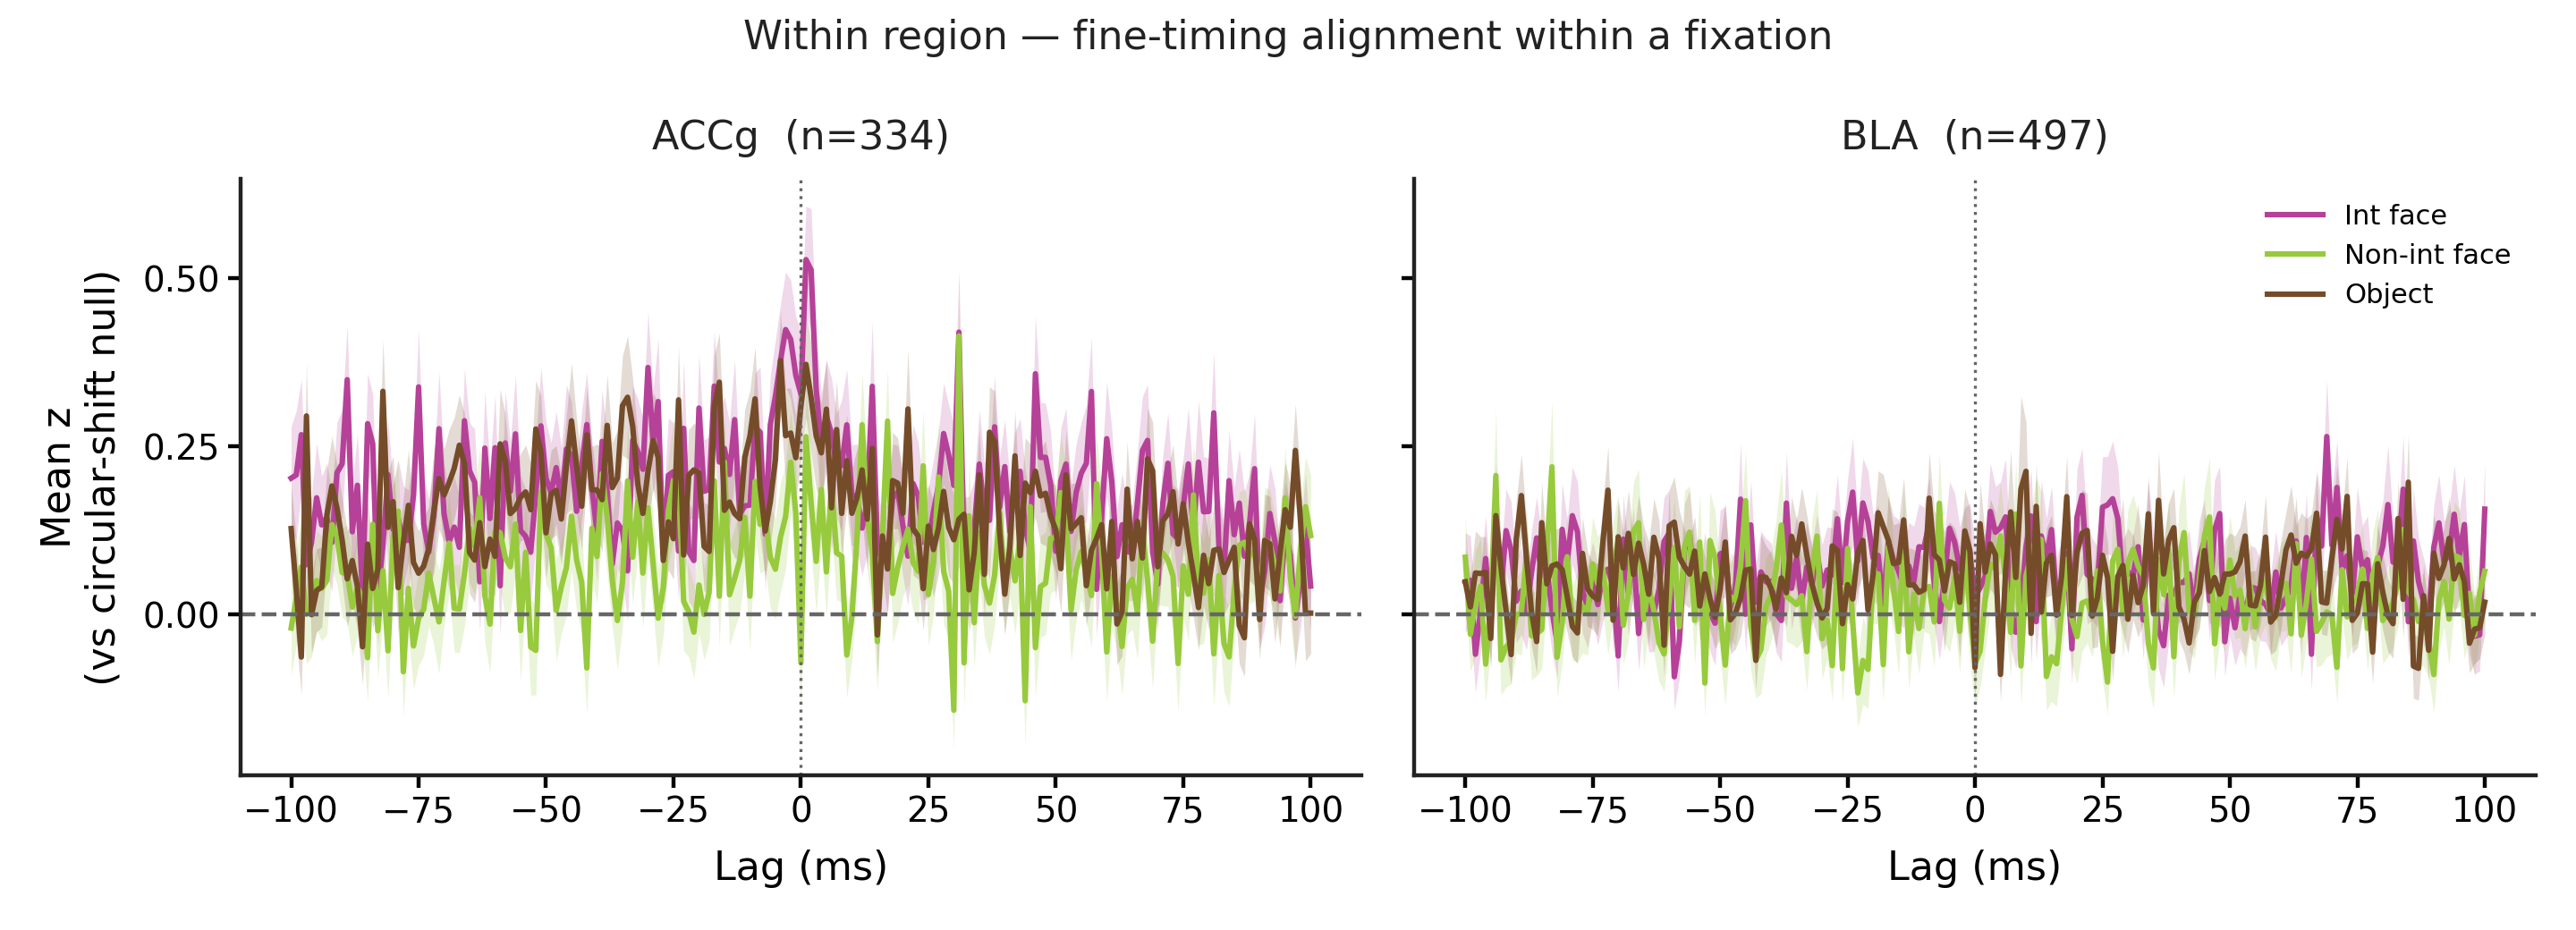

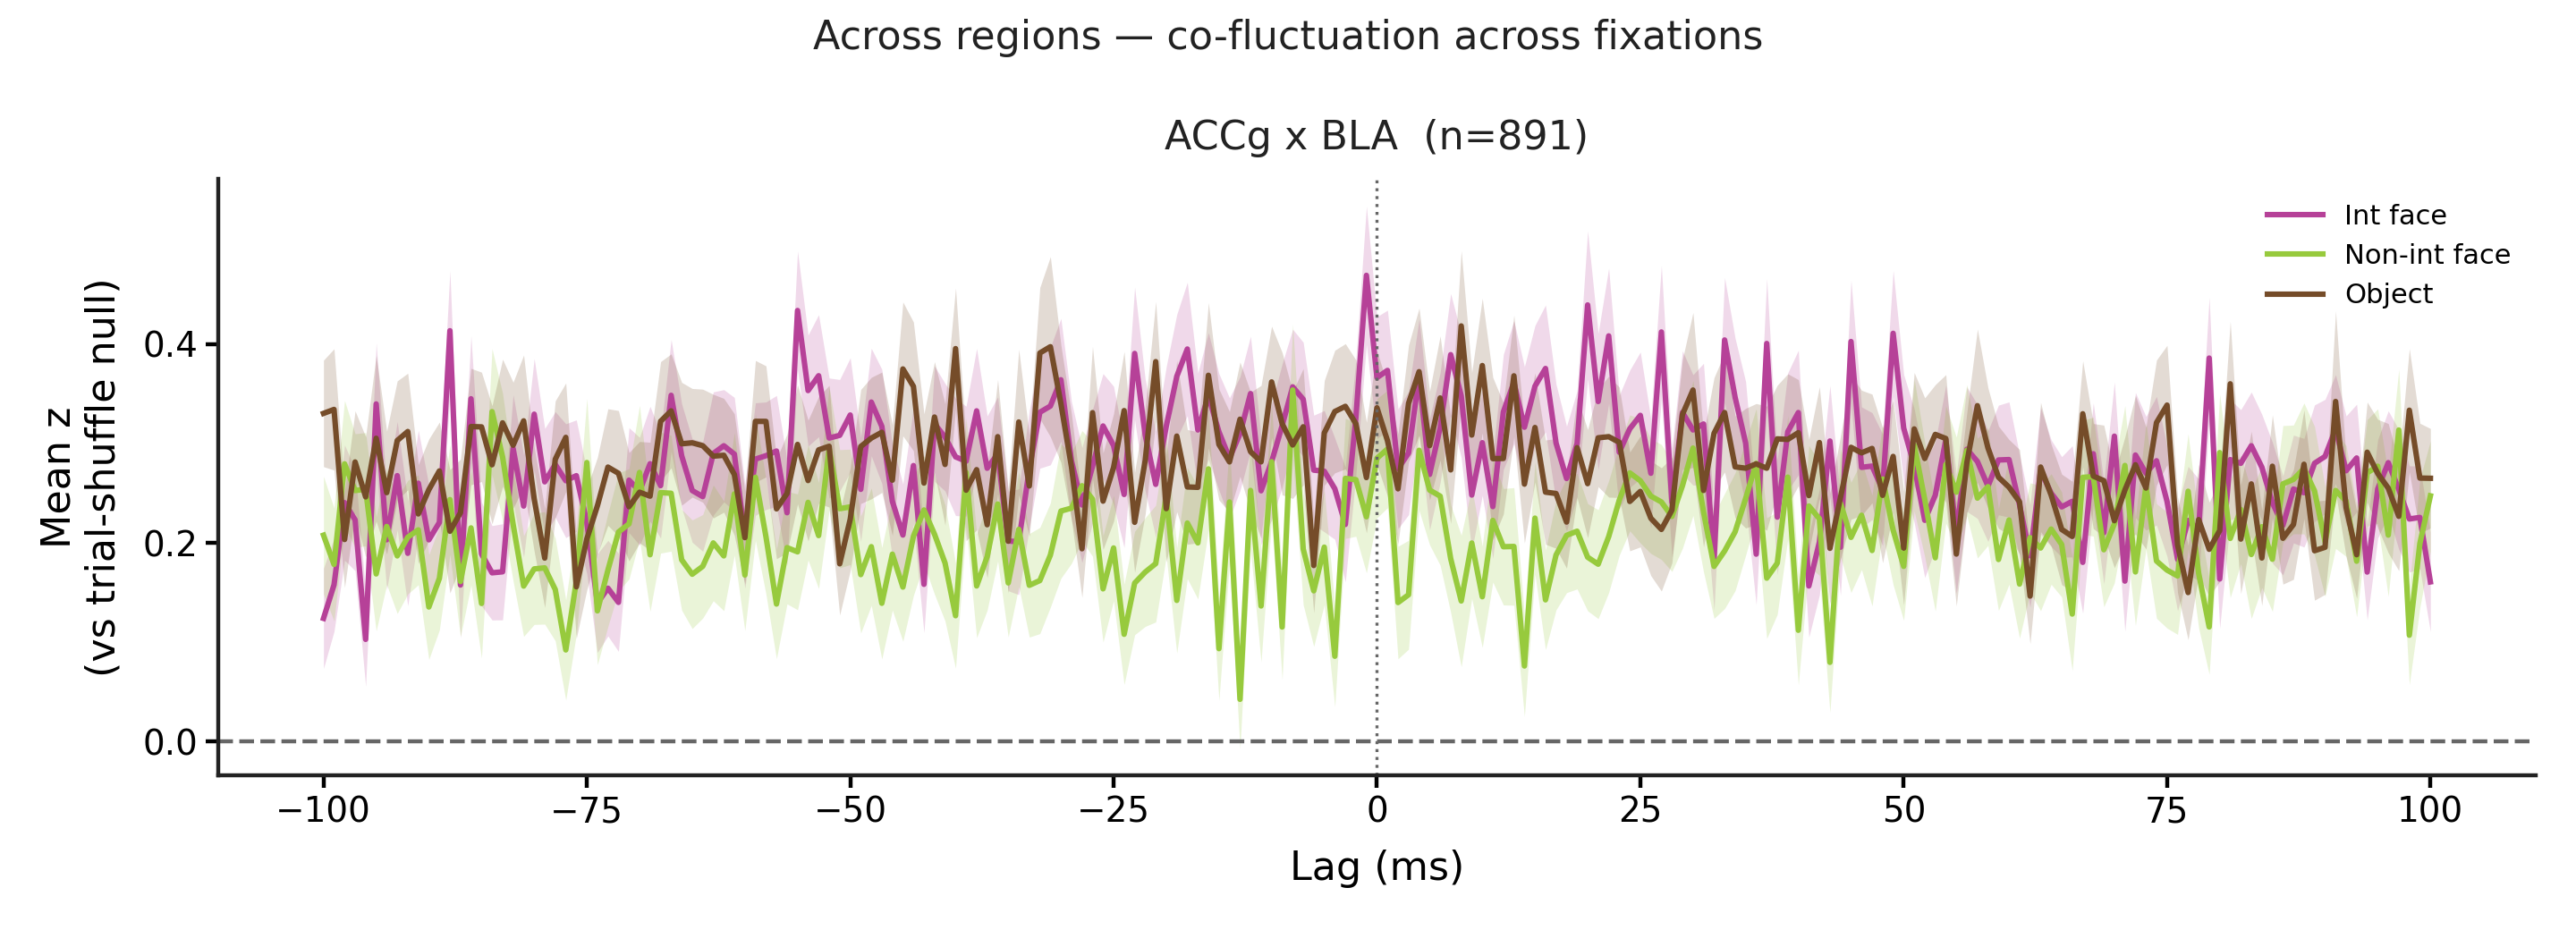

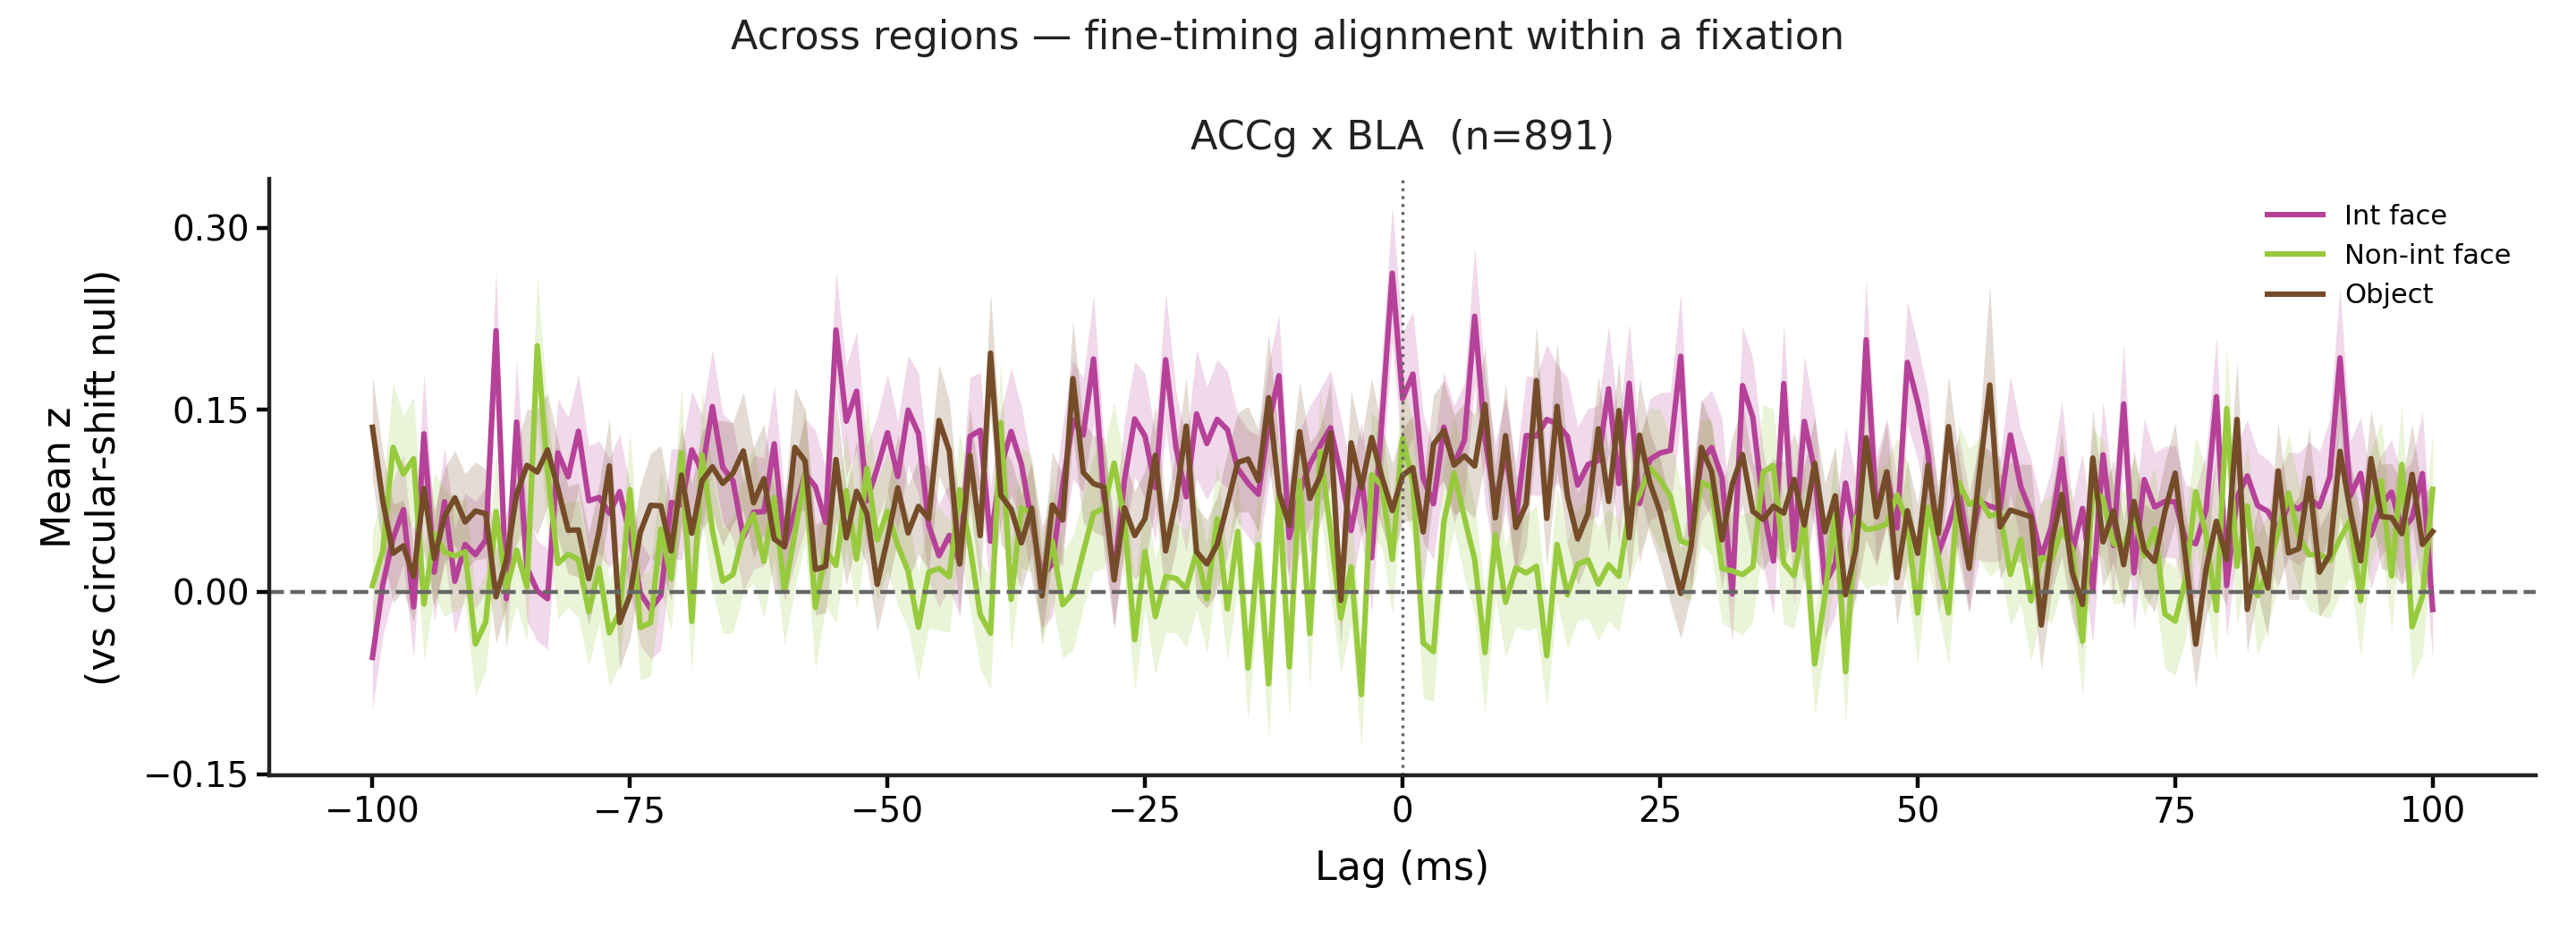

In [6]:
by_region = pd.read_pickle(SUMMARY_DIR / "group_traces_by_region.pkl")

for scope in ("within_region", "cross_region"):
    for null_name in ("trial_shuffle", "circular_shift"):
        fig, paths = viz.plot_region_traces(
            by_region, fig_settings, scope=scope, null_name=null_name
        )
        display(Image(filename=str(paths["png"])))

### Is coordination above null, region by region?

One-sample Wilcoxon signed-rank test of the per-pair excess against zero, per
region and condition. This is the *is there anything there* question, answered
before any pooling.

,scope,region_pair,condition,n_pairs,mean_excess,median_excess,statistic,p_value
0,cross_region,accg-bla,face_interactive,883,0.0593,0.0353,310315.0,0.0000
1,cross_region,accg-bla,face_non_interactive,666,0.0499,0.0140,149035.0,0.0000
2,cross_region,accg-bla,object,891,0.0517,0.0222,292940.0,0.0000
3,within_region,accg,face_interactive,334,0.1262,0.1001,52885.0,0.0000
4,within_region,accg,face_non_interactive,258,0.1587,0.1077,30355.0,0.0000
5,within_region,accg,object,325,0.1176,0.0683,48386.0,0.0000
6,within_region,bla,face_interactive,476,0.0395,0.0184,79094.0,0.0000
7,within_region,bla,face_non_interactive,347,0.0265,-0.0055,33669.0,0.0314
8,within_region,bla,object,497,0.0257,0.0063,78090.0,0.0000


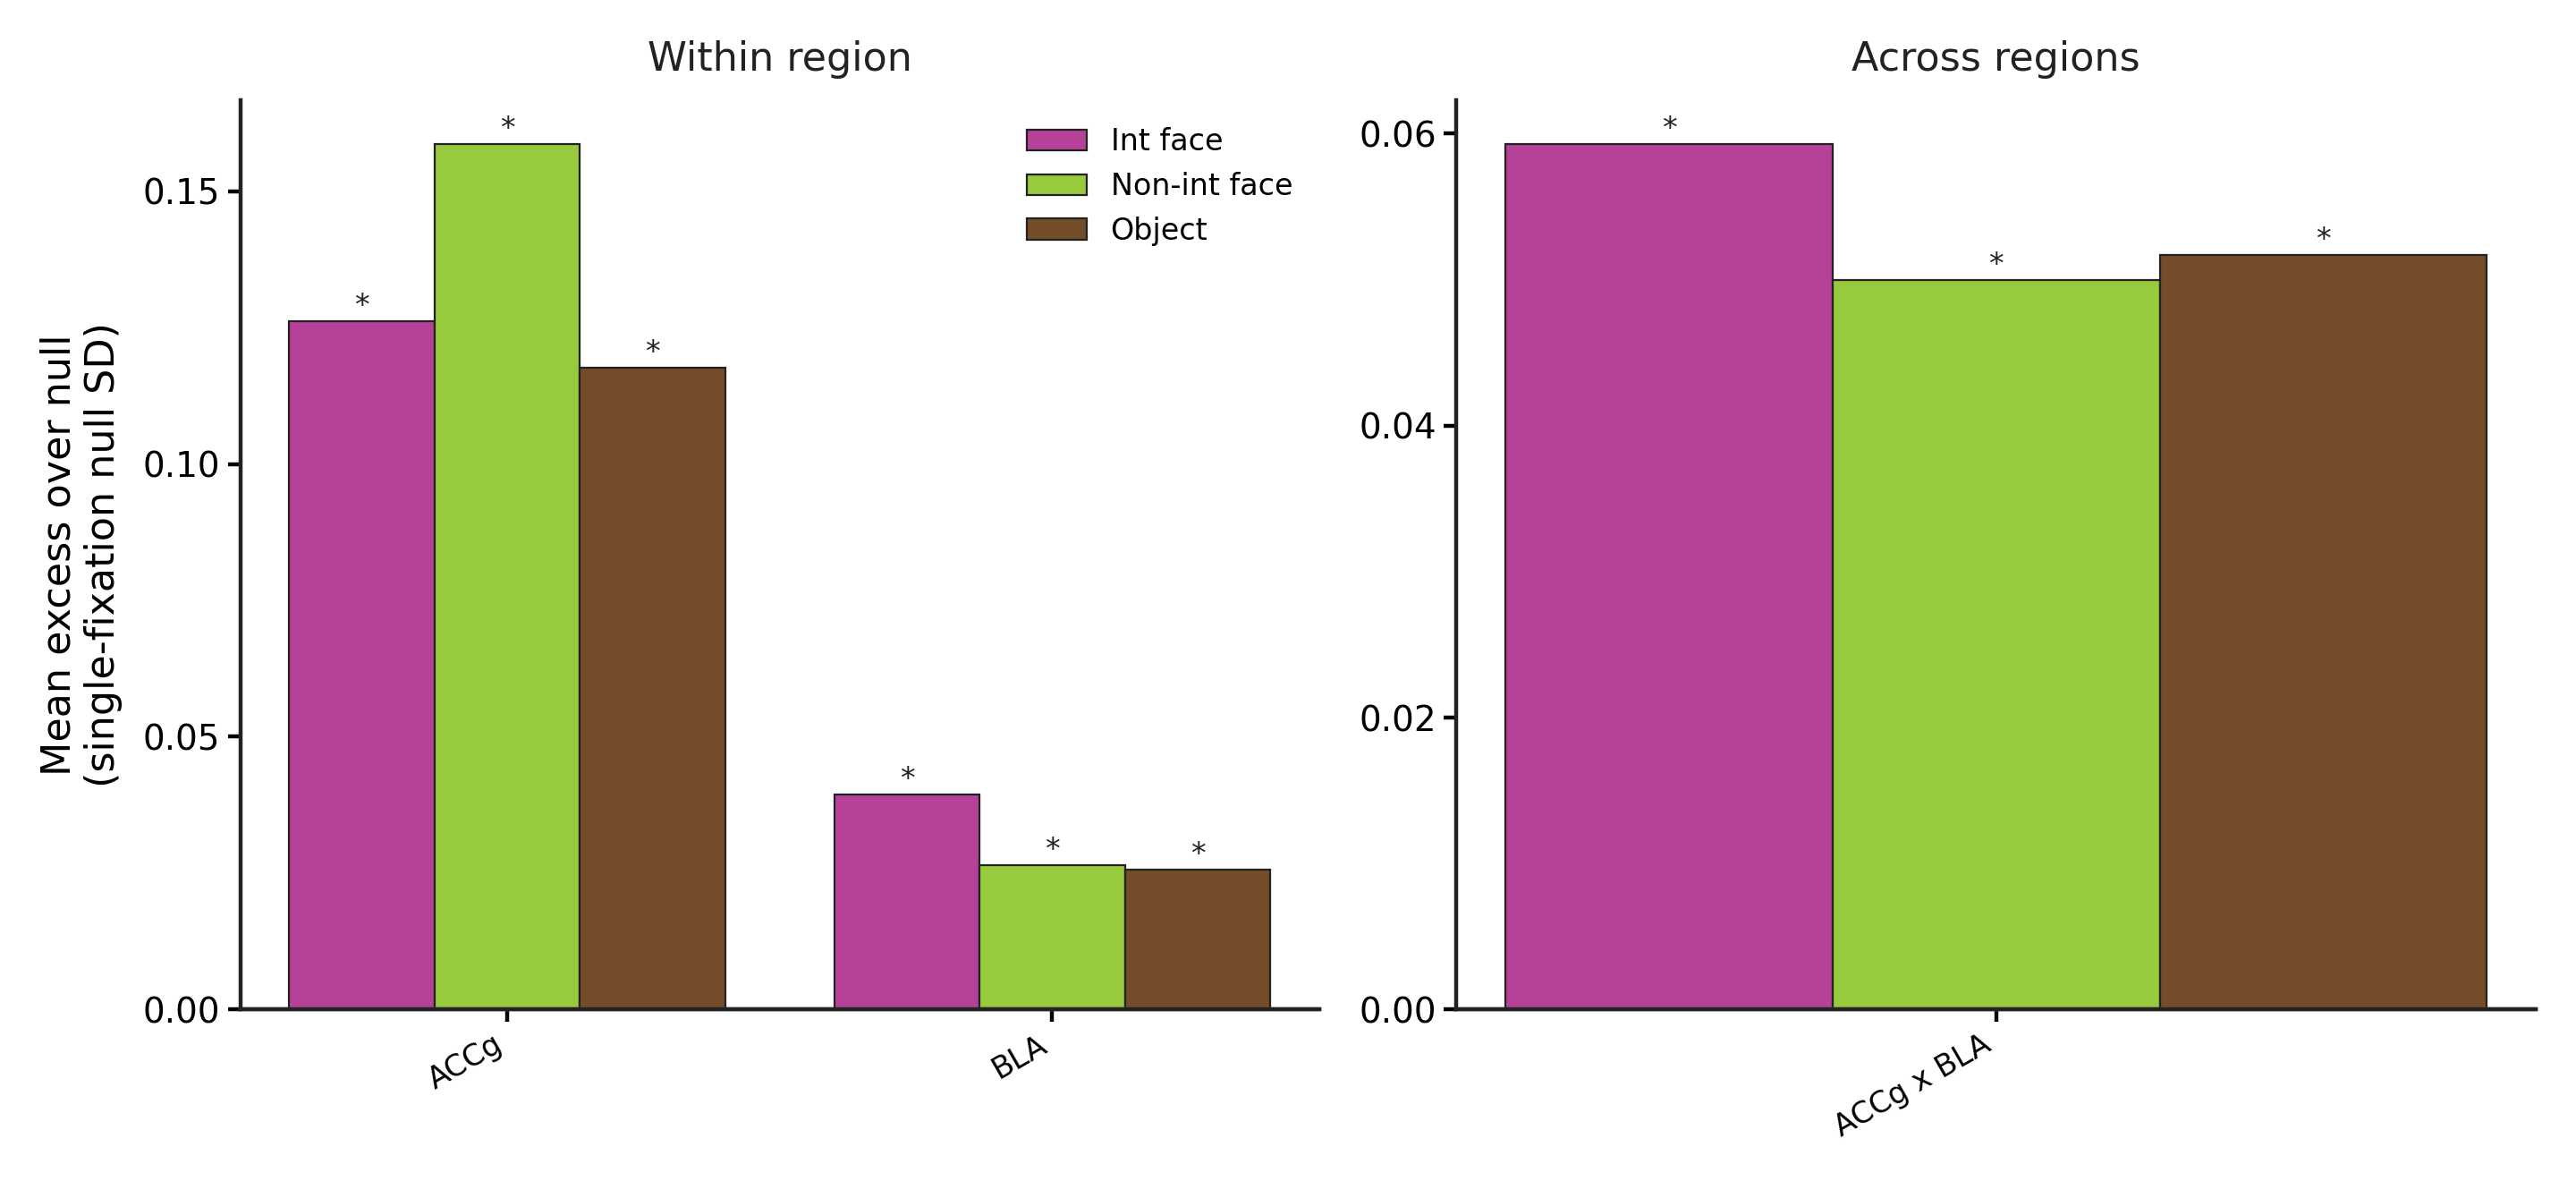

In [7]:
vs_null_by_region = pd.read_csv(SUMMARY_DIR / "coordination_vs_null_by_region.csv")
display(vs_null_by_region.round(4))

fig, paths = viz.plot_region_condition_tests(vs_null_by_region, fig_settings)
display(Image(filename=str(paths["png"])))

## 5. Condition effects per region

Bootstrap confidence intervals on the per-pair effect, by region and region
pair.

,scope,region_pair,condition,n_pairs,n_pairs_finite,mean,sem,median,ci_low,ci_high,median_n_fixations,frac_pairs_above_null,mean_z
0,cross_region,accg-bla,face_interactive,883,883,0.0593,0.0036,0.0353,0.0524,0.0665,35.0,0.0159,0.3219
1,cross_region,accg-bla,face_non_interactive,666,666,0.0499,0.0053,0.0140,0.0397,0.0603,19.0,0.0330,0.2111
2,cross_region,accg-bla,object,891,891,0.0517,0.0057,0.0222,0.0410,0.0636,37.0,0.0236,0.3129
3,within_region,accg,face_interactive,334,334,0.1262,0.0075,0.1001,0.1118,0.1411,35.0,0.0509,0.7004
4,within_region,accg,face_non_interactive,258,258,0.1587,0.0127,0.1077,0.1356,0.1841,19.0,0.0465,0.6066
5,within_region,accg,object,325,325,0.1176,0.0131,0.0683,0.0947,0.1435,37.0,0.0615,0.7008
6,within_region,bla,face_interactive,476,476,0.0395,0.0044,0.0184,0.0308,0.0482,35.0,0.0147,0.2150
7,within_region,bla,face_non_interactive,347,347,0.0265,0.0062,-0.0055,0.0143,0.0392,19.0,0.0086,0.1210
8,within_region,bla,object,497,497,0.0257,0.0041,0.0063,0.0179,0.0341,37.0,0.0141,0.1586


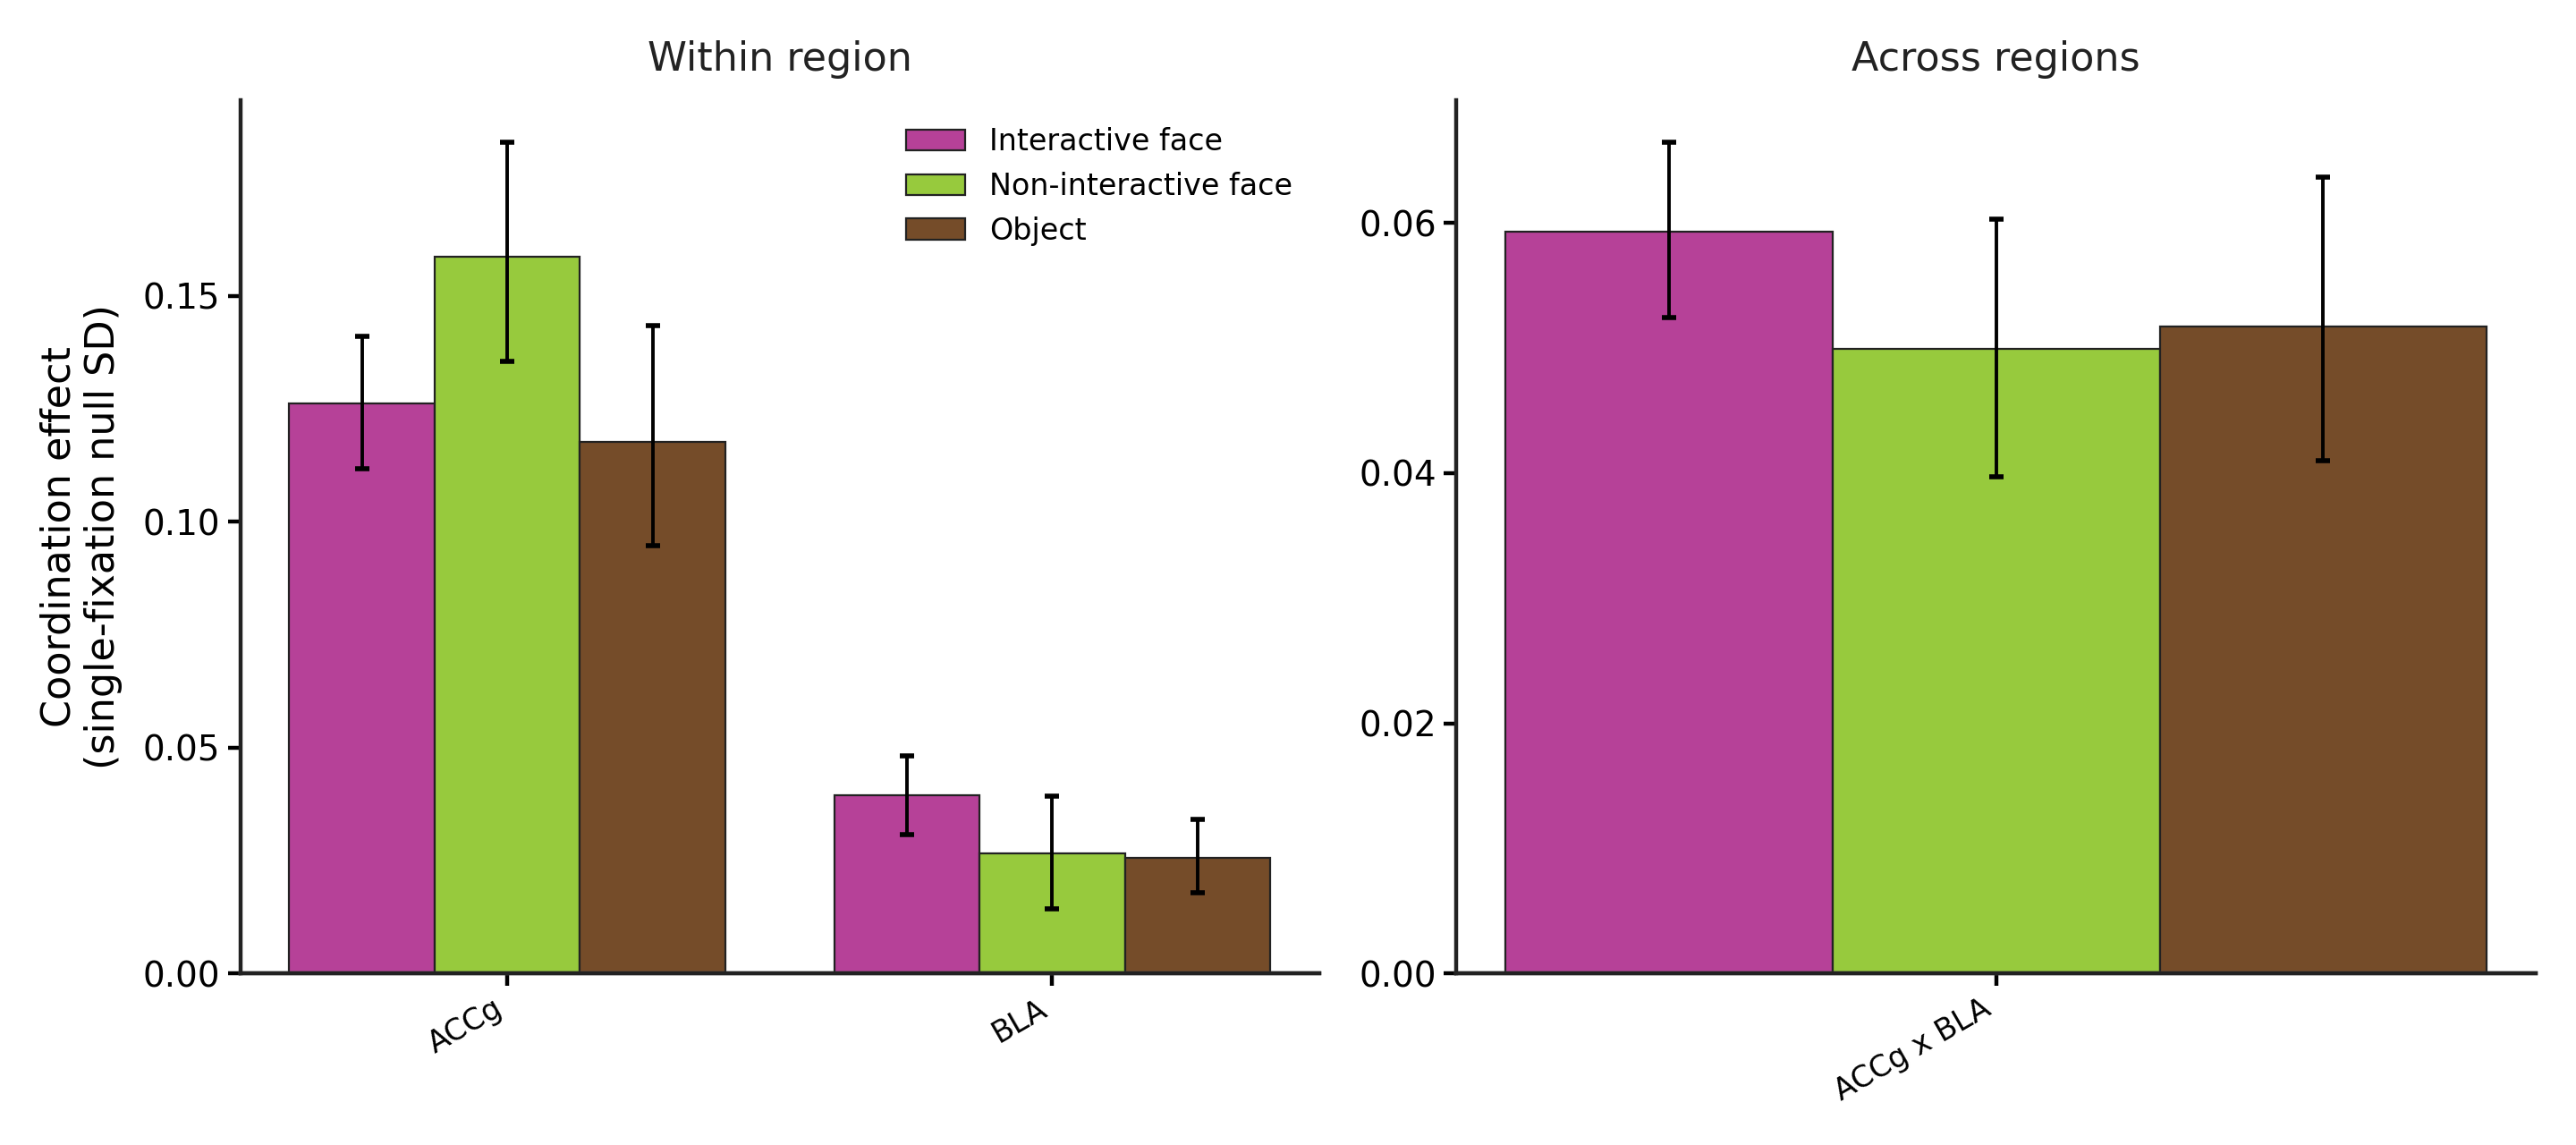

In [8]:
summary_by_region = pd.read_csv(SUMMARY_DIR / "coordination_summary_by_region.csv")
display(summary_by_region.round(4))

fig, paths = viz.plot_condition_effects(summary_by_region, fig_settings)
display(Image(filename=str(paths["png"])))

### Does interactive face change coordination, region by region?

Comparisons are **paired within pair**: the same two neurons, the same
electrodes, the same session, differing only in which fixations were used. That
removes pair identity, firing rate and recording quality in one step.
Benjamini–Hochberg corrected across the reported contrasts.

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,639,0.0505,0.0517,-0.0012,91707.0,0.0241,0.0829,0.0371,True,fdr_bh
1,cross_region,accg-bla,face_interactive,object,844,0.0619,0.0552,0.0067,149931.0,0.0001,0.1090,0.0006,True,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,648,0.0496,0.0510,-0.0014,97589.0,0.1133,-0.0833,0.1133,False,fdr_bh
3,within_region,accg,face_interactive,face_non_interactive,258,0.1108,0.1587,-0.0479,14011.0,0.0247,-0.0853,0.0371,True,fdr_bh
4,within_region,accg,face_interactive,object,316,0.1320,0.1201,0.0119,20465.0,0.0049,0.1456,0.0109,True,fdr_bh
5,within_region,accg,face_non_interactive,object,258,0.1587,0.1003,0.0584,12272.0,0.0002,0.1860,0.0010,True,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,318,0.0329,0.0307,0.0023,22291.0,0.0614,0.0566,0.0789,False,fdr_bh
7,within_region,bla,face_interactive,object,455,0.0407,0.0266,0.0141,43553.0,0.0030,0.0637,0.0091,True,fdr_bh
8,within_region,bla,face_non_interactive,object,328,0.0278,0.0309,-0.0031,24176.0,0.1030,-0.0915,0.1133,False,fdr_bh


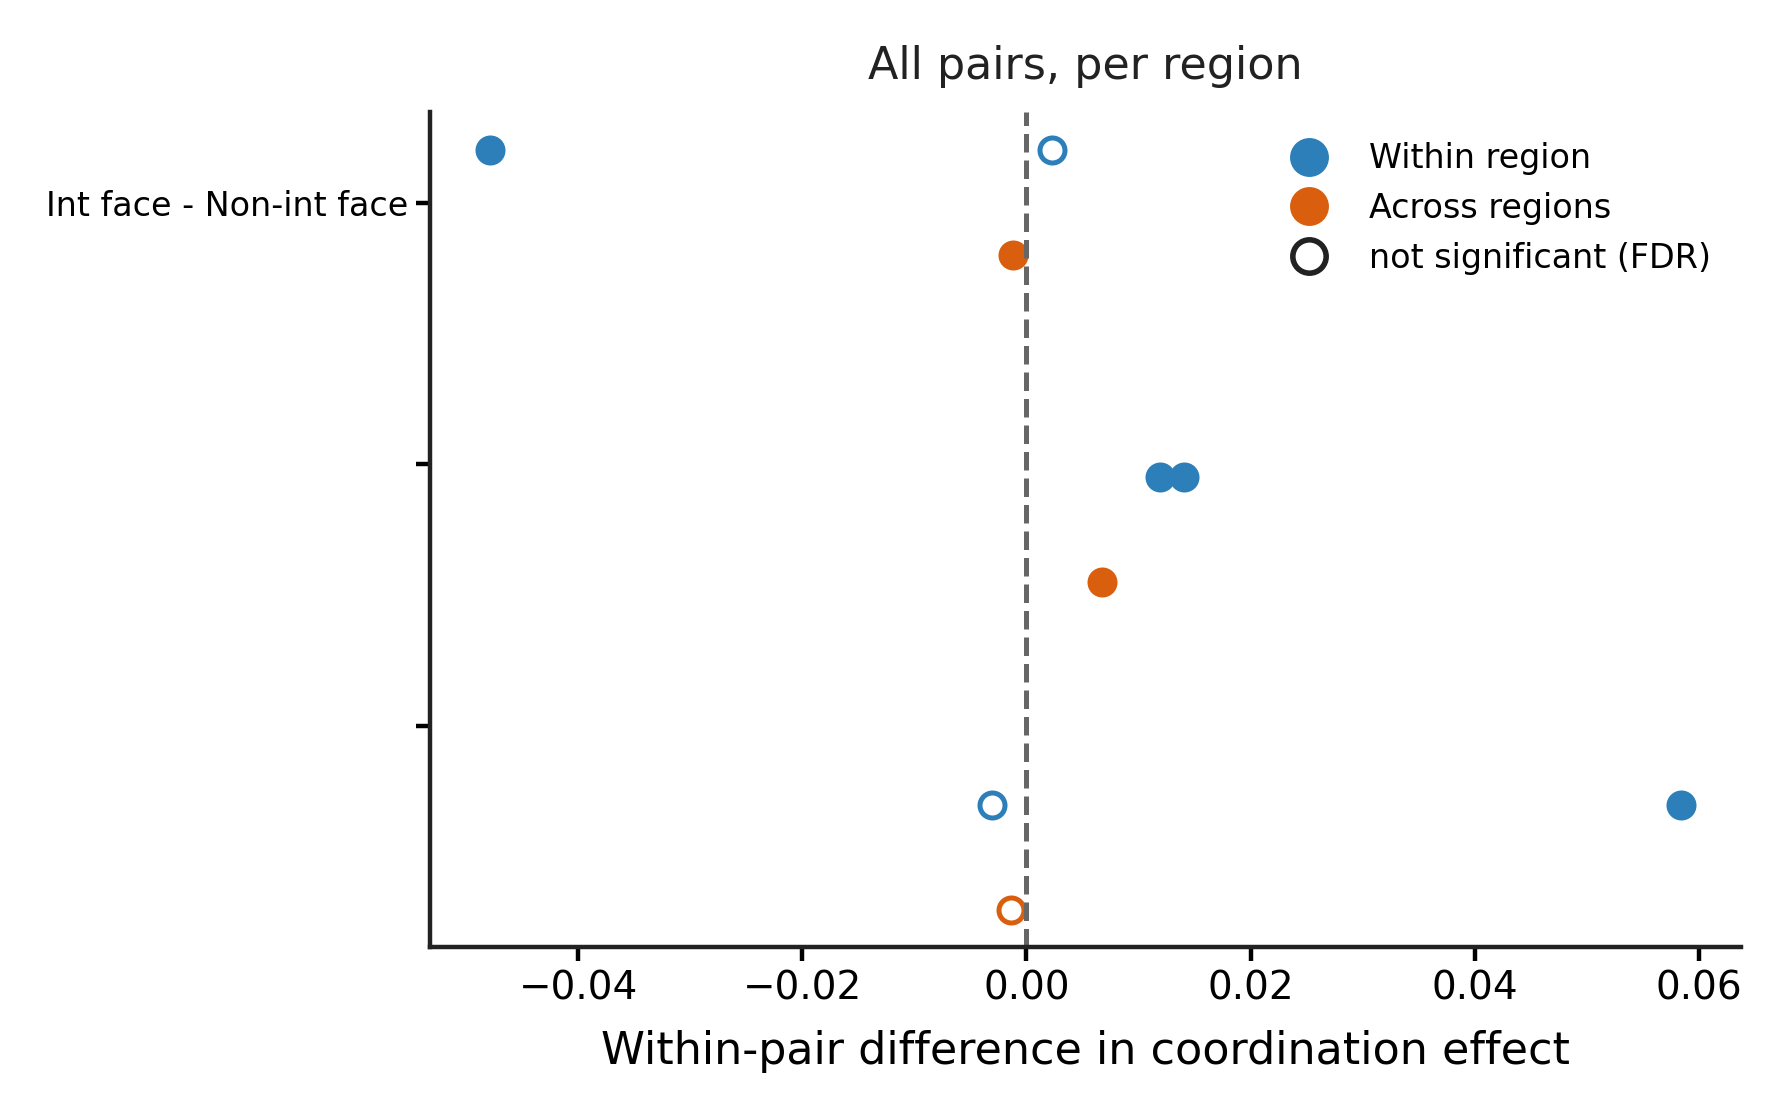

In [9]:
by_region_contrasts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region.csv")
display(by_region_contrasts.round(4))

fig, paths = viz.plot_condition_contrasts(
    by_region_contrasts, fig_settings,
    label="All pairs, per region", stem="fig05_condition_contrasts_by_region",
)
display(Image(filename=str(paths["png"])))

## 6. Pooled across regions

The same quantities pooled to scope level, as a summary of the region-resolved
results above. Read these *after* section 5, and treat a pooled effect that no
individual region shows as a composition artifact rather than a finding.

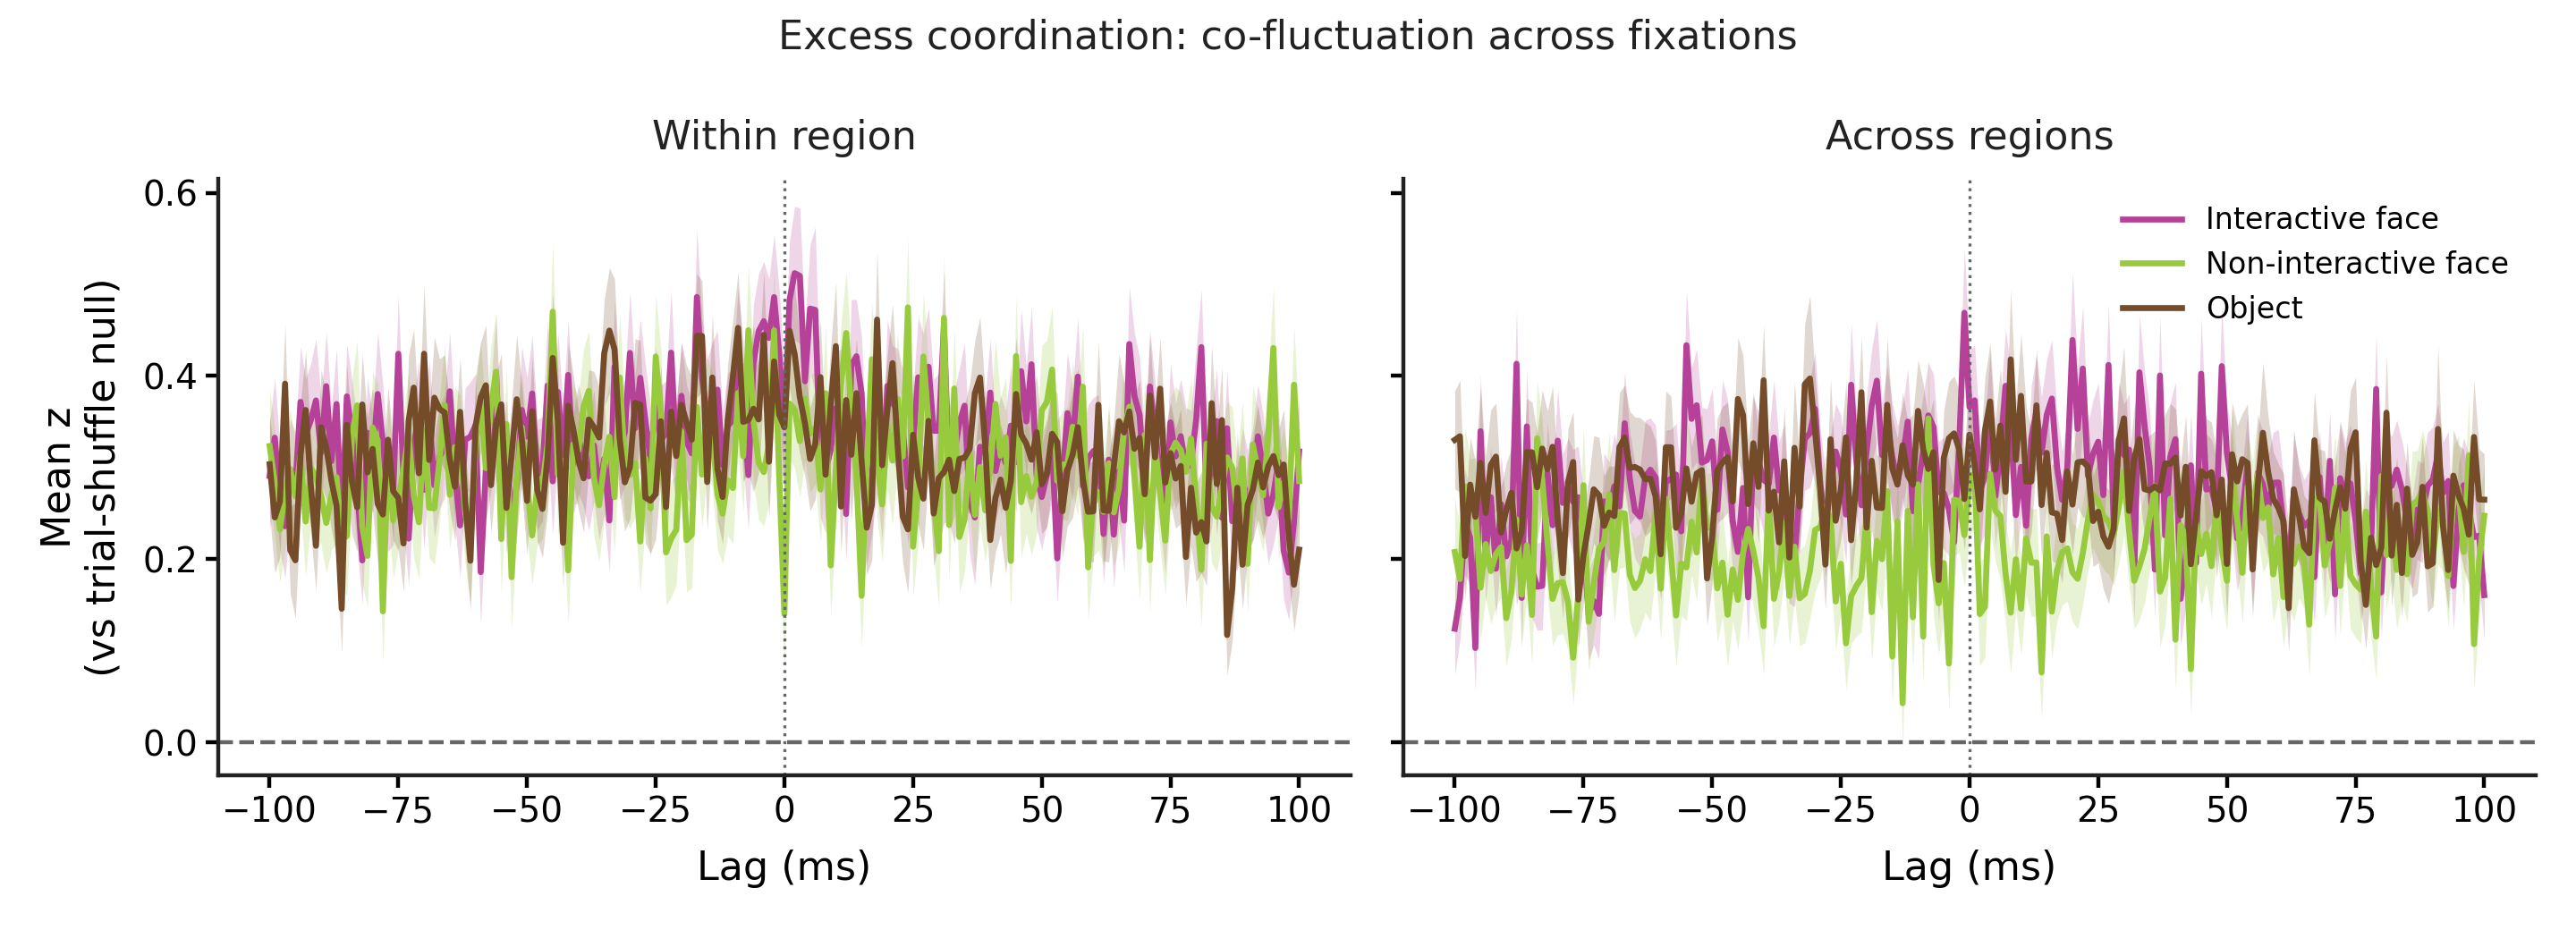

,scope,condition,n_pairs,mean_excess,median_excess,statistic,p_value
0,cross_region,face_interactive,883,0.0593,0.0353,310315.0,0.0
1,cross_region,face_non_interactive,666,0.0499,0.0140,149035.0,0.0
2,cross_region,object,891,0.0517,0.0222,292940.0,0.0
3,within_region,face_interactive,810,0.0752,0.0473,270175.0,0.0
4,within_region,face_non_interactive,605,0.0829,0.0312,134552.0,0.0
5,within_region,object,822,0.0621,0.0300,259232.0,0.0


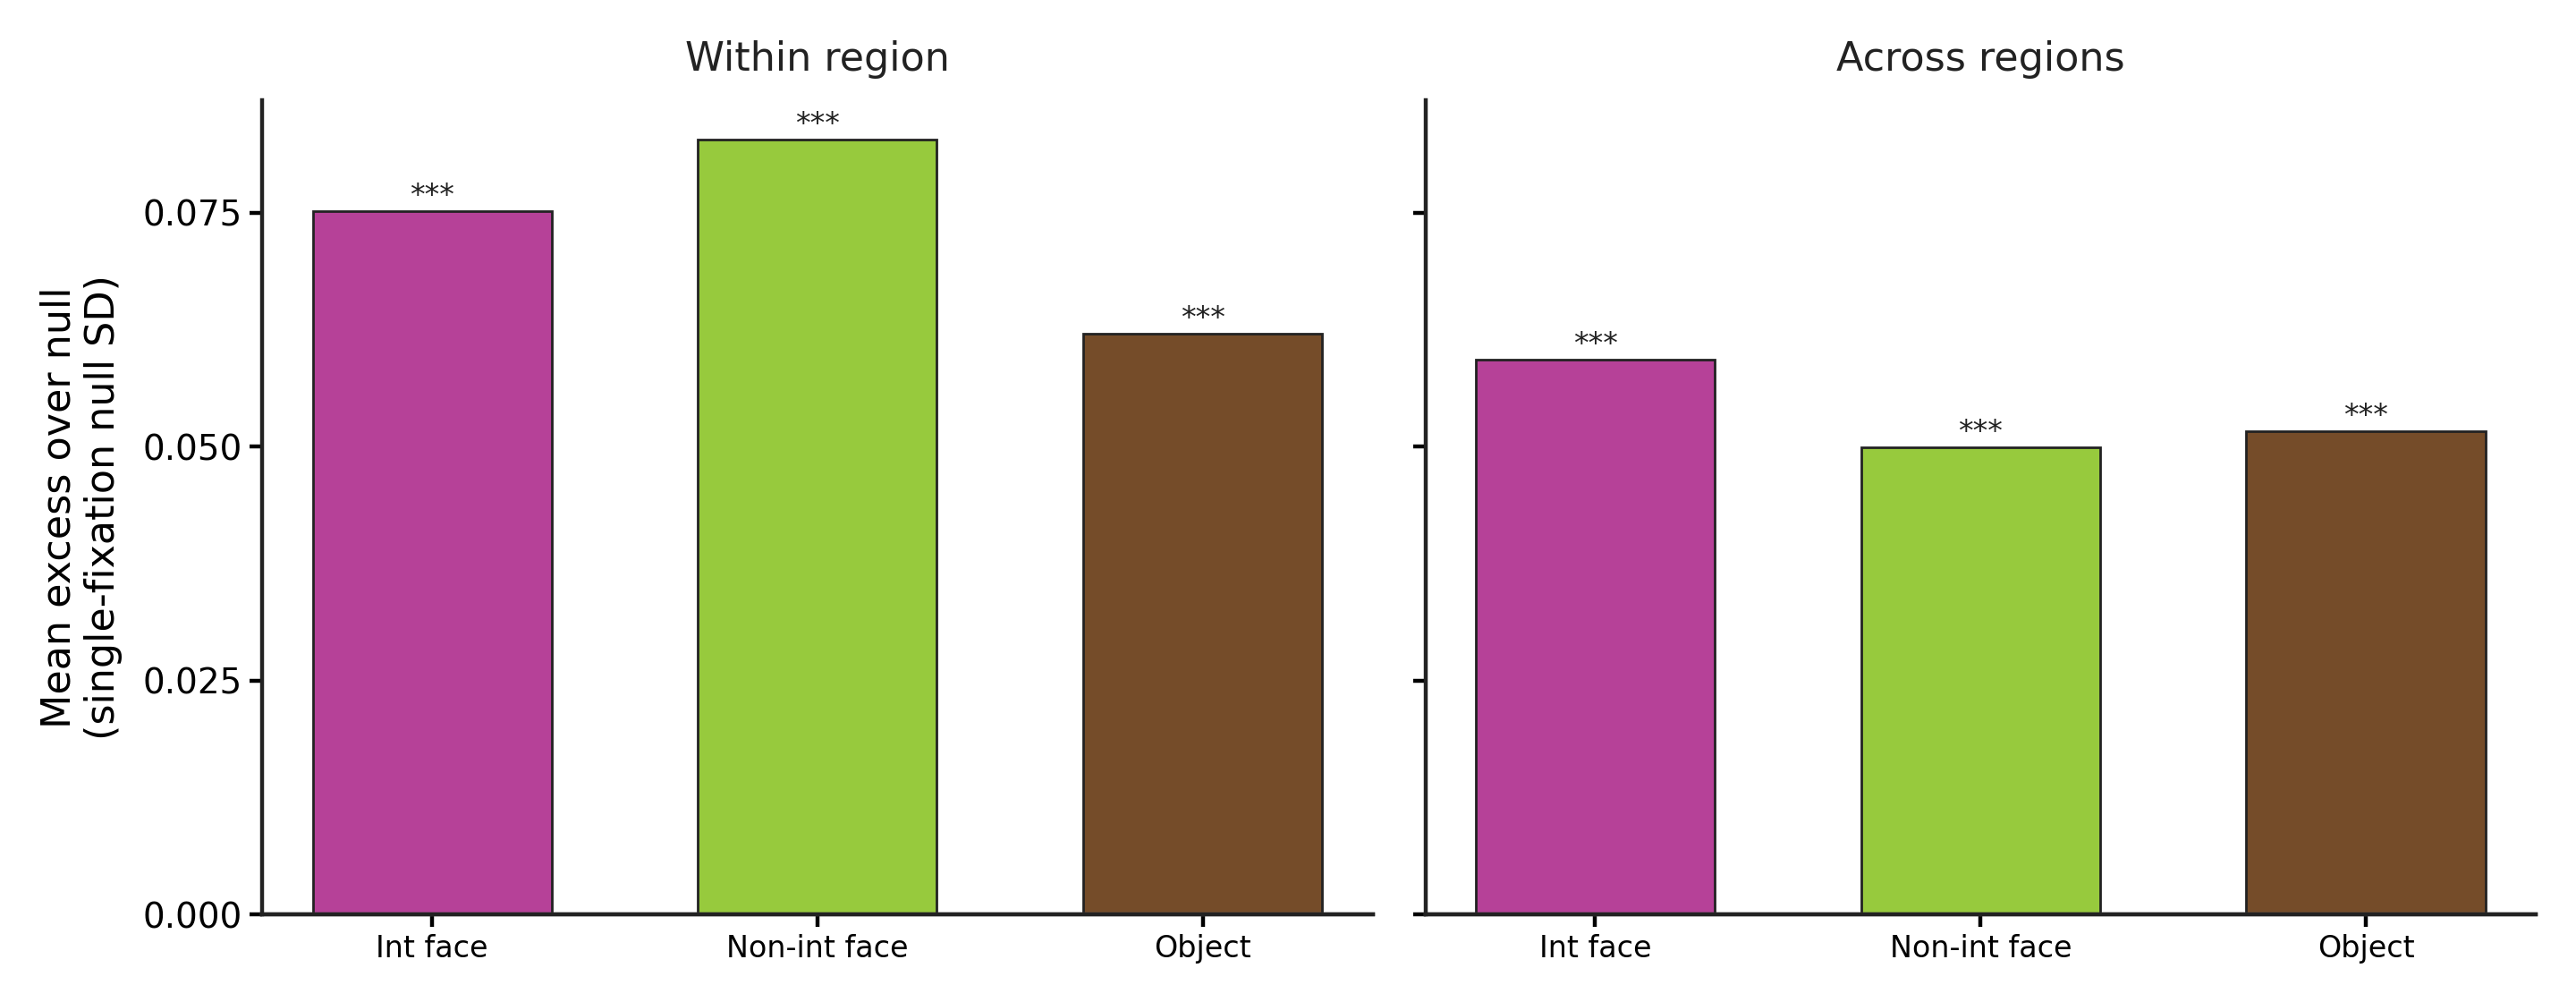

,scope,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,face_interactive,face_non_interactive,639,0.0505,0.0517,-0.0012,91707.0,0.0241,0.0829,0.0481,True,fdr_bh
1,cross_region,face_interactive,object,844,0.0619,0.0552,0.0067,149931.0,0.0001,0.1090,0.0002,True,fdr_bh
2,cross_region,face_non_interactive,object,648,0.0496,0.0510,-0.0014,97589.0,0.1133,-0.0833,0.1360,False,fdr_bh
3,within_region,face_interactive,face_non_interactive,576,0.0678,0.0880,-0.0202,81758.0,0.7393,-0.0069,0.7393,False,fdr_bh
4,within_region,face_interactive,object,771,0.0781,0.0650,0.0132,123038.0,0.0000,0.0973,0.0002,True,fdr_bh
5,within_region,face_non_interactive,object,586,0.0854,0.0615,0.0240,79088.0,0.0921,0.0307,0.1360,False,fdr_bh


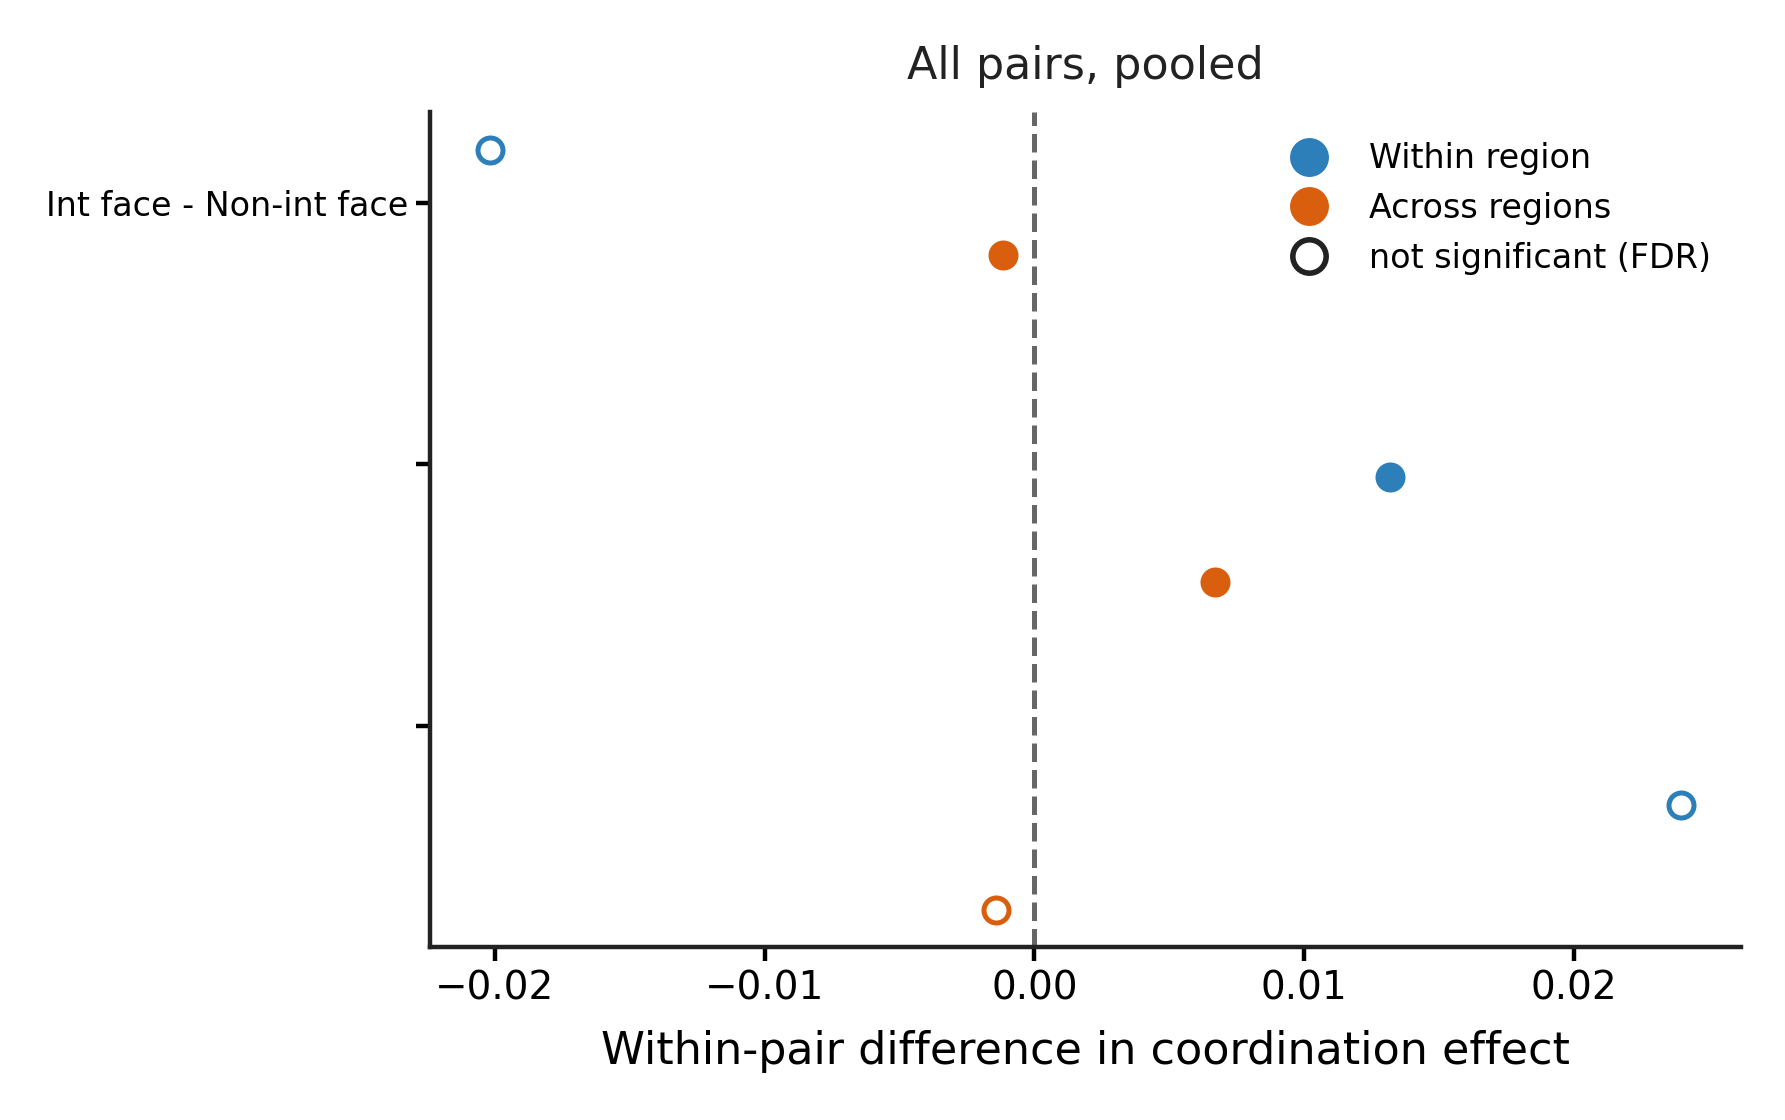

In [10]:
fig, paths = viz.plot_group_z_traces(by_scope, fig_settings, null_name="trial_shuffle")
display(Image(filename=str(paths["png"])))

vs_null = pd.read_csv(SUMMARY_DIR / "coordination_vs_null.csv")
display(vs_null.round(4))
fig, paths = viz.plot_excess_vs_null(vs_null, fig_settings)
display(Image(filename=str(paths["png"])))

comparisons = pd.read_csv(SUMMARY_DIR / "condition_comparisons.csv")
display(comparisons.round(4))
fig, paths = viz.plot_condition_contrasts(comparisons, fig_settings, label="All pairs, pooled", stem="fig08_condition_contrasts_pooled")
display(Image(filename=str(paths["png"])))

## 7. Control: trial-count matching

The `effect` metric is already built not to scale with trial count. This is the
direct check: every pair recomputed on a common fixation count across
conditions. **If a condition difference survives here, trial count is not
driving it.**

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,639,0.0440,0.0518,-0.0078,98353.0,0.4051,0.0548,0.4557,False,fdr_bh
1,cross_region,accg-bla,face_interactive,object,756,0.0382,0.0785,-0.0403,128564.5,0.0251,-0.0810,0.0564,False,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,648,0.0493,0.0708,-0.0215,94455.0,0.0250,-0.1204,0.0564,False,fdr_bh
3,within_region,accg,face_interactive,face_non_interactive,258,0.1185,0.1679,-0.0494,14474.0,0.0629,-0.0775,0.1132,False,fdr_bh
4,within_region,accg,face_interactive,object,288,0.1172,0.1494,-0.0322,20340.0,0.8179,0.0314,0.8179,False,fdr_bh
5,within_region,accg,face_non_interactive,object,258,0.1679,0.1106,0.0573,12139.0,0.0001,0.1550,0.0013,True,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,318,0.0169,0.0365,-0.0196,23554.0,0.2709,-0.0189,0.3929,False,fdr_bh
7,within_region,bla,face_interactive,object,400,0.0116,0.0336,-0.0220,33830.5,0.0163,-0.0909,0.0564,False,fdr_bh
8,within_region,bla,face_non_interactive,object,328,0.0341,0.0444,-0.0103,25217.0,0.3056,-0.0610,0.3929,False,fdr_bh


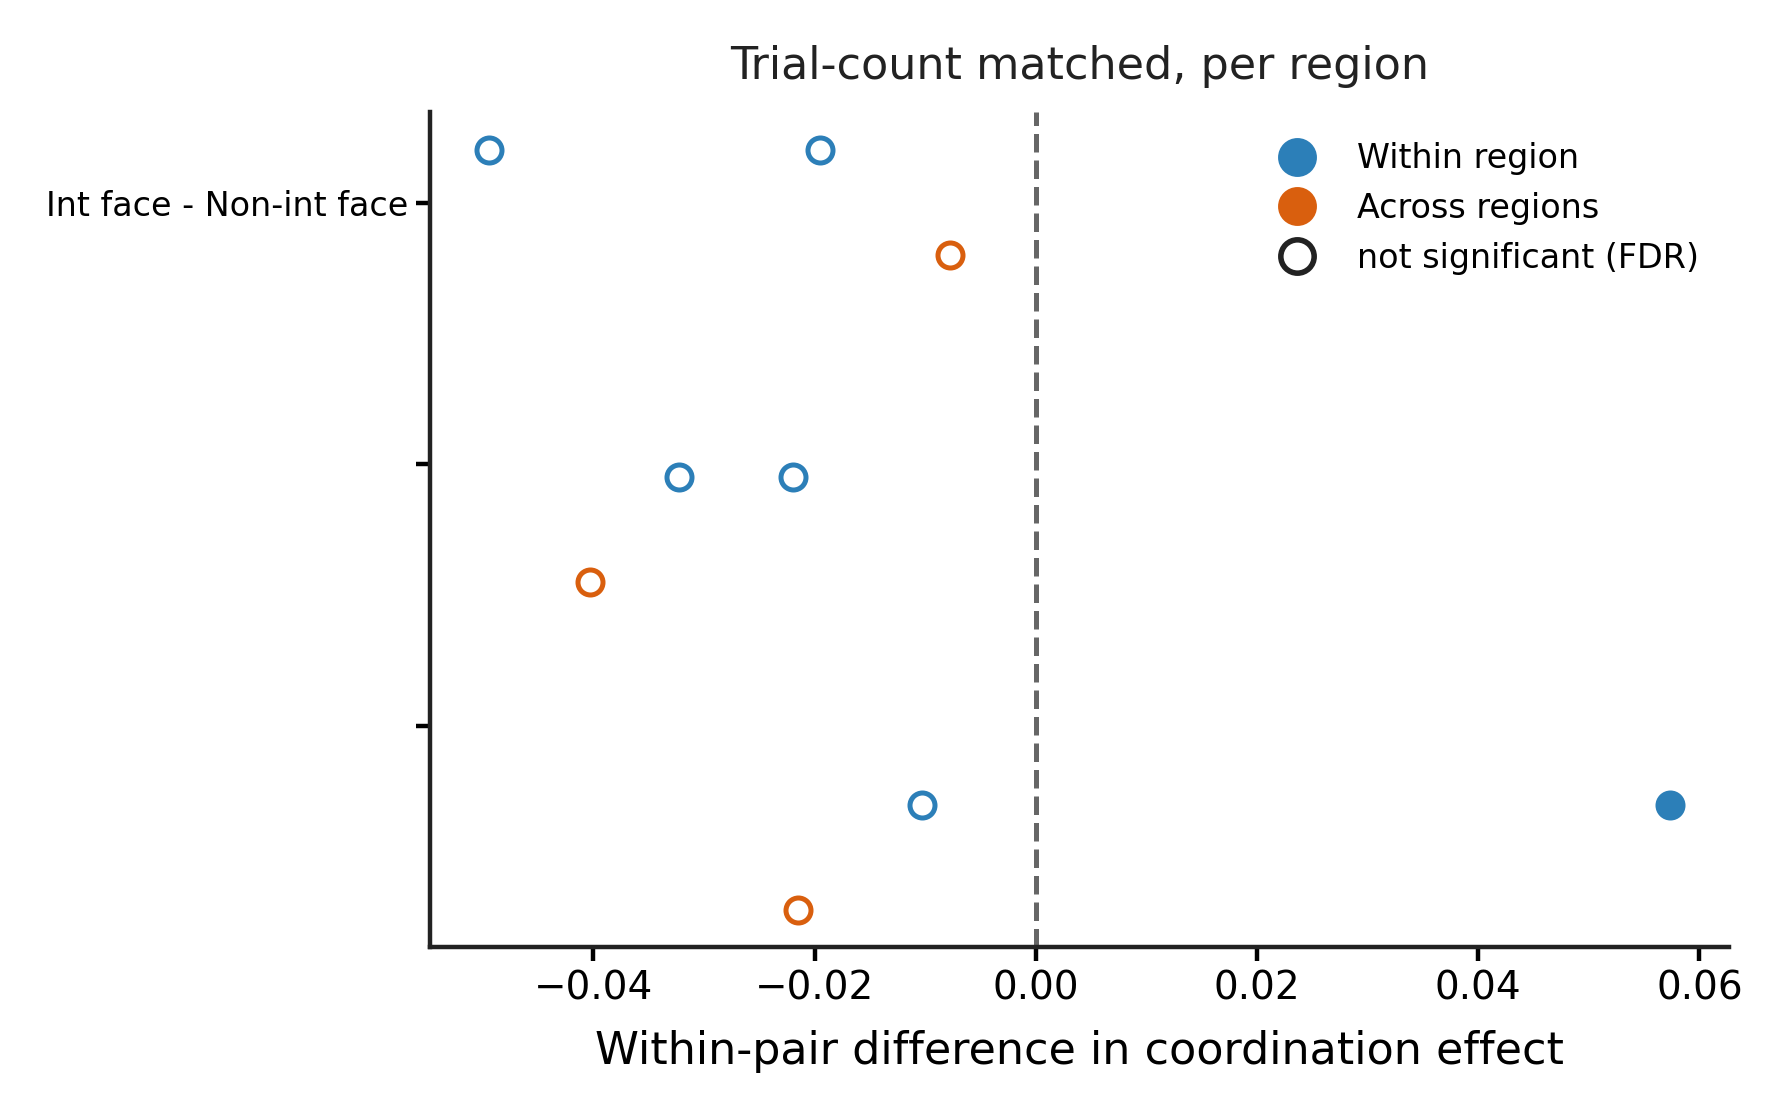

,scope,region_pair,condition_a,condition_b,mean_difference_full,mean_difference_matched,significant_full,significant_matched
0,cross_region,accg-bla,face_interactive,face_non_interactive,-0.0012,-0.0078,True,False
1,cross_region,accg-bla,face_interactive,object,0.0067,-0.0403,True,False
2,cross_region,accg-bla,face_non_interactive,object,-0.0014,-0.0215,False,False
3,within_region,accg,face_interactive,face_non_interactive,-0.0479,-0.0494,True,False
4,within_region,accg,face_interactive,object,0.0119,-0.0322,True,False
5,within_region,accg,face_non_interactive,object,0.0584,0.0573,True,True
6,within_region,bla,face_interactive,face_non_interactive,0.0023,-0.0196,False,False
7,within_region,bla,face_interactive,object,0.0141,-0.0220,True,False
8,within_region,bla,face_non_interactive,object,-0.0031,-0.0103,False,False


In [11]:
matched_metric = EFFECT_METRIC + "_matched"
if matched_metric in pairs.columns and pairs[matched_metric].notna().any():
    matched = psc.compare_conditions(
        pairs, metric=matched_metric, group_columns=("scope", "region_pair")
    )
    display(matched.round(4))
    fig, paths = viz.plot_condition_contrasts(
        matched, fig_settings,
        label="Trial-count matched, per region", stem="fig09_contrasts_matched",
    )
    display(Image(filename=str(paths["png"])))
    merged = by_region_contrasts.merge(
        matched, on=["scope", "region_pair", "condition_a", "condition_b"],
        suffixes=("_full", "_matched"),
    )
    display(
        merged.loc[
            :,
            ["scope", "region_pair", "condition_a", "condition_b",
             "mean_difference_full", "mean_difference_matched",
             "significant_full", "significant_matched"],
        ].round(4)
    )
else:
    display(Markdown("_Trial-count-matched columns are absent; rebuild with `trial_match_conditions: true`._"))

## 8. Pairs where both units are FDR-selective

Everything above used **all** recorded pairs. This repeats it on pairs where
both units are significantly selective for at least one fixation-condition
contrast (FDR-corrected, `three_condition_core`).

This is a sensitivity check, not independent confirmation — selecting units by a
condition contrast and then asking whether coordination differs by condition is
circular. What it can legitimately show is whether an effect is carried by the
selective subset or is distributed across the population.

pairs with both units FDR-selective: 2,170 of 4,677 (46.4%)


,scope,condition,n_pairs,n_pairs_both_selective,n_dates,n_sessions,median_n_fixations
0,cross_region,face_interactive,414,414,1,9,37.0
1,cross_region,face_non_interactive,326,326,1,8,19.0
2,cross_region,object,428,428,1,9,37.0
3,within_region,face_interactive,356,356,1,9,37.0
4,within_region,face_non_interactive,279,279,1,8,19.0
5,within_region,object,367,367,1,9,37.0


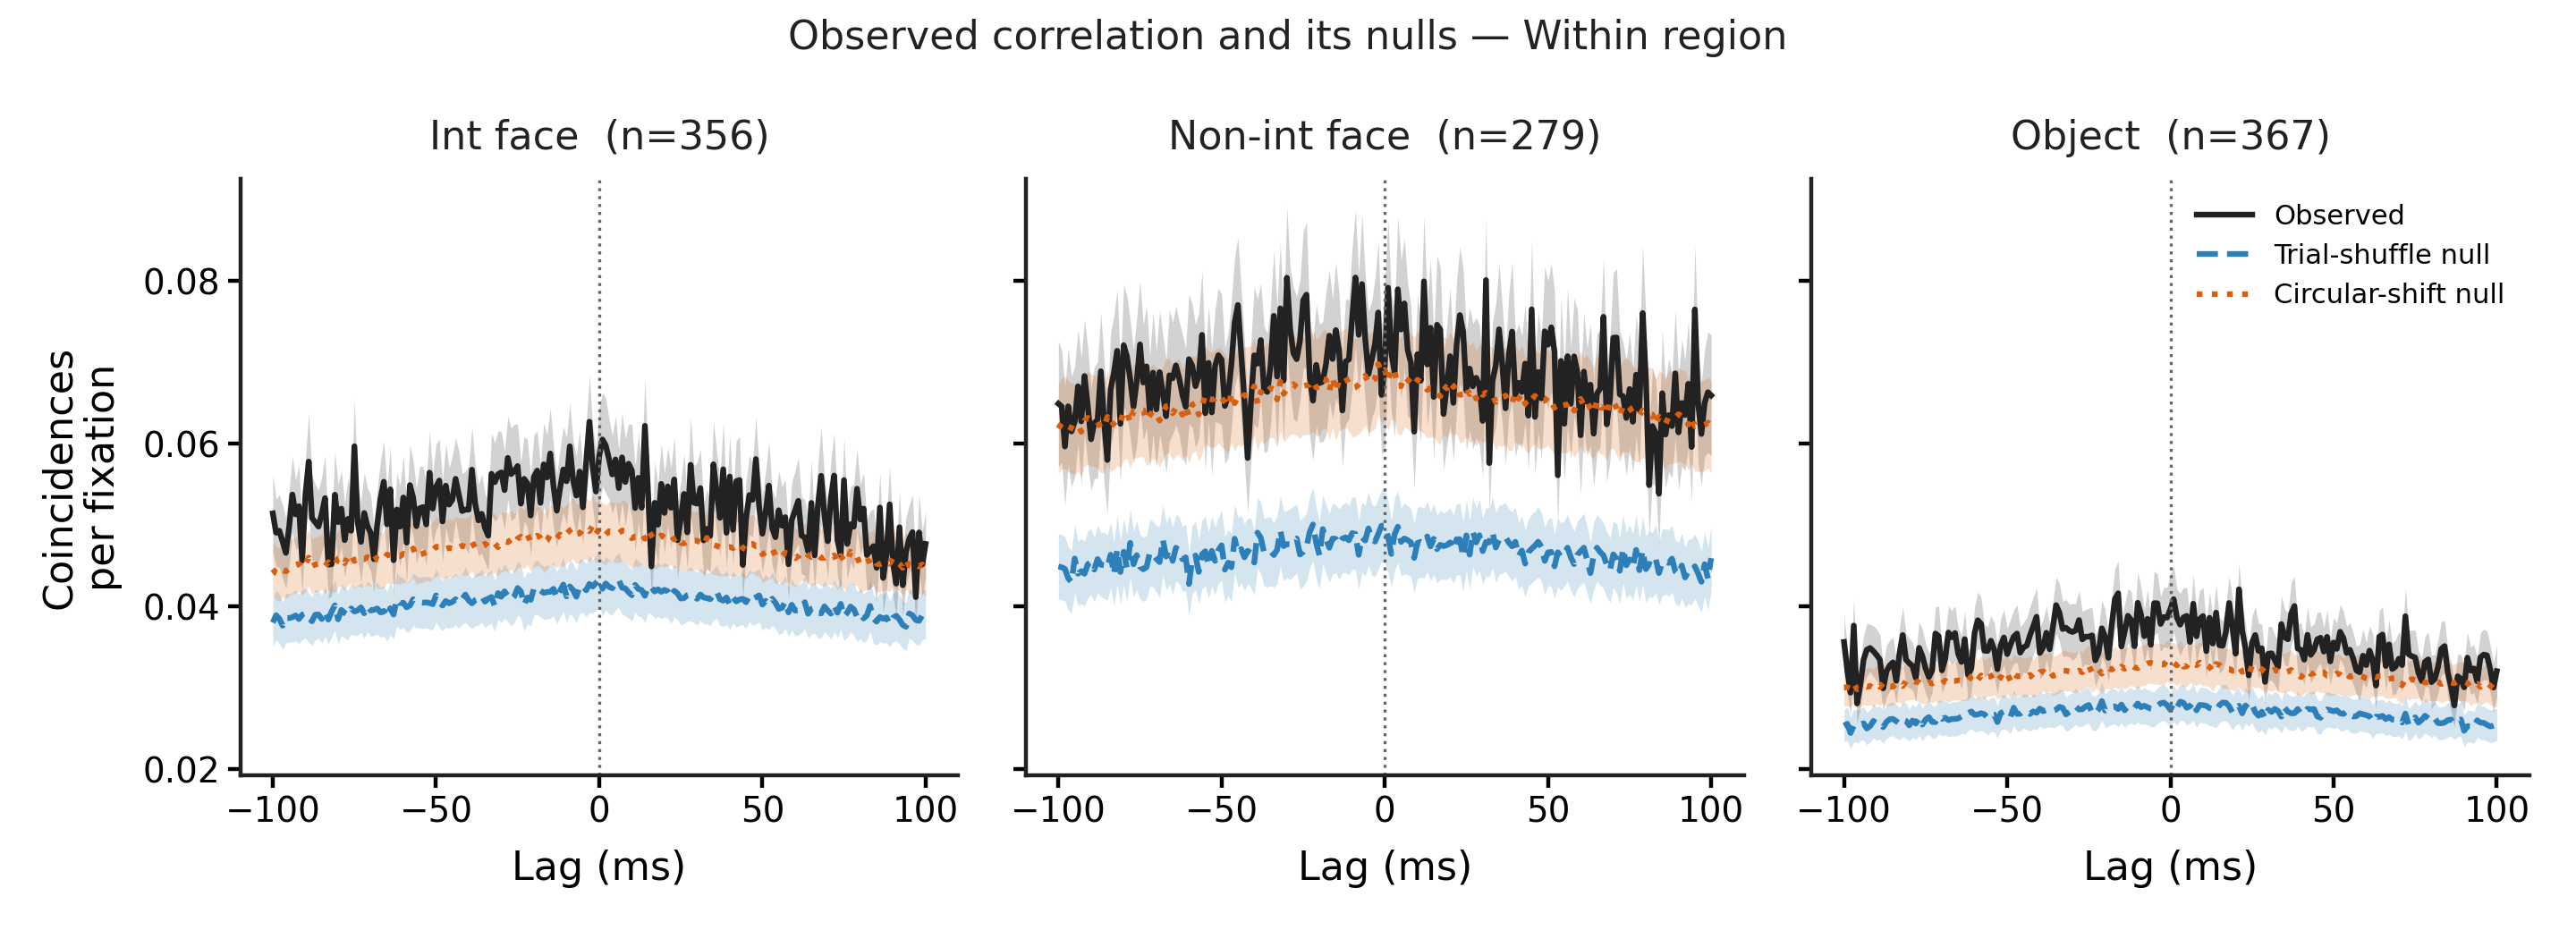

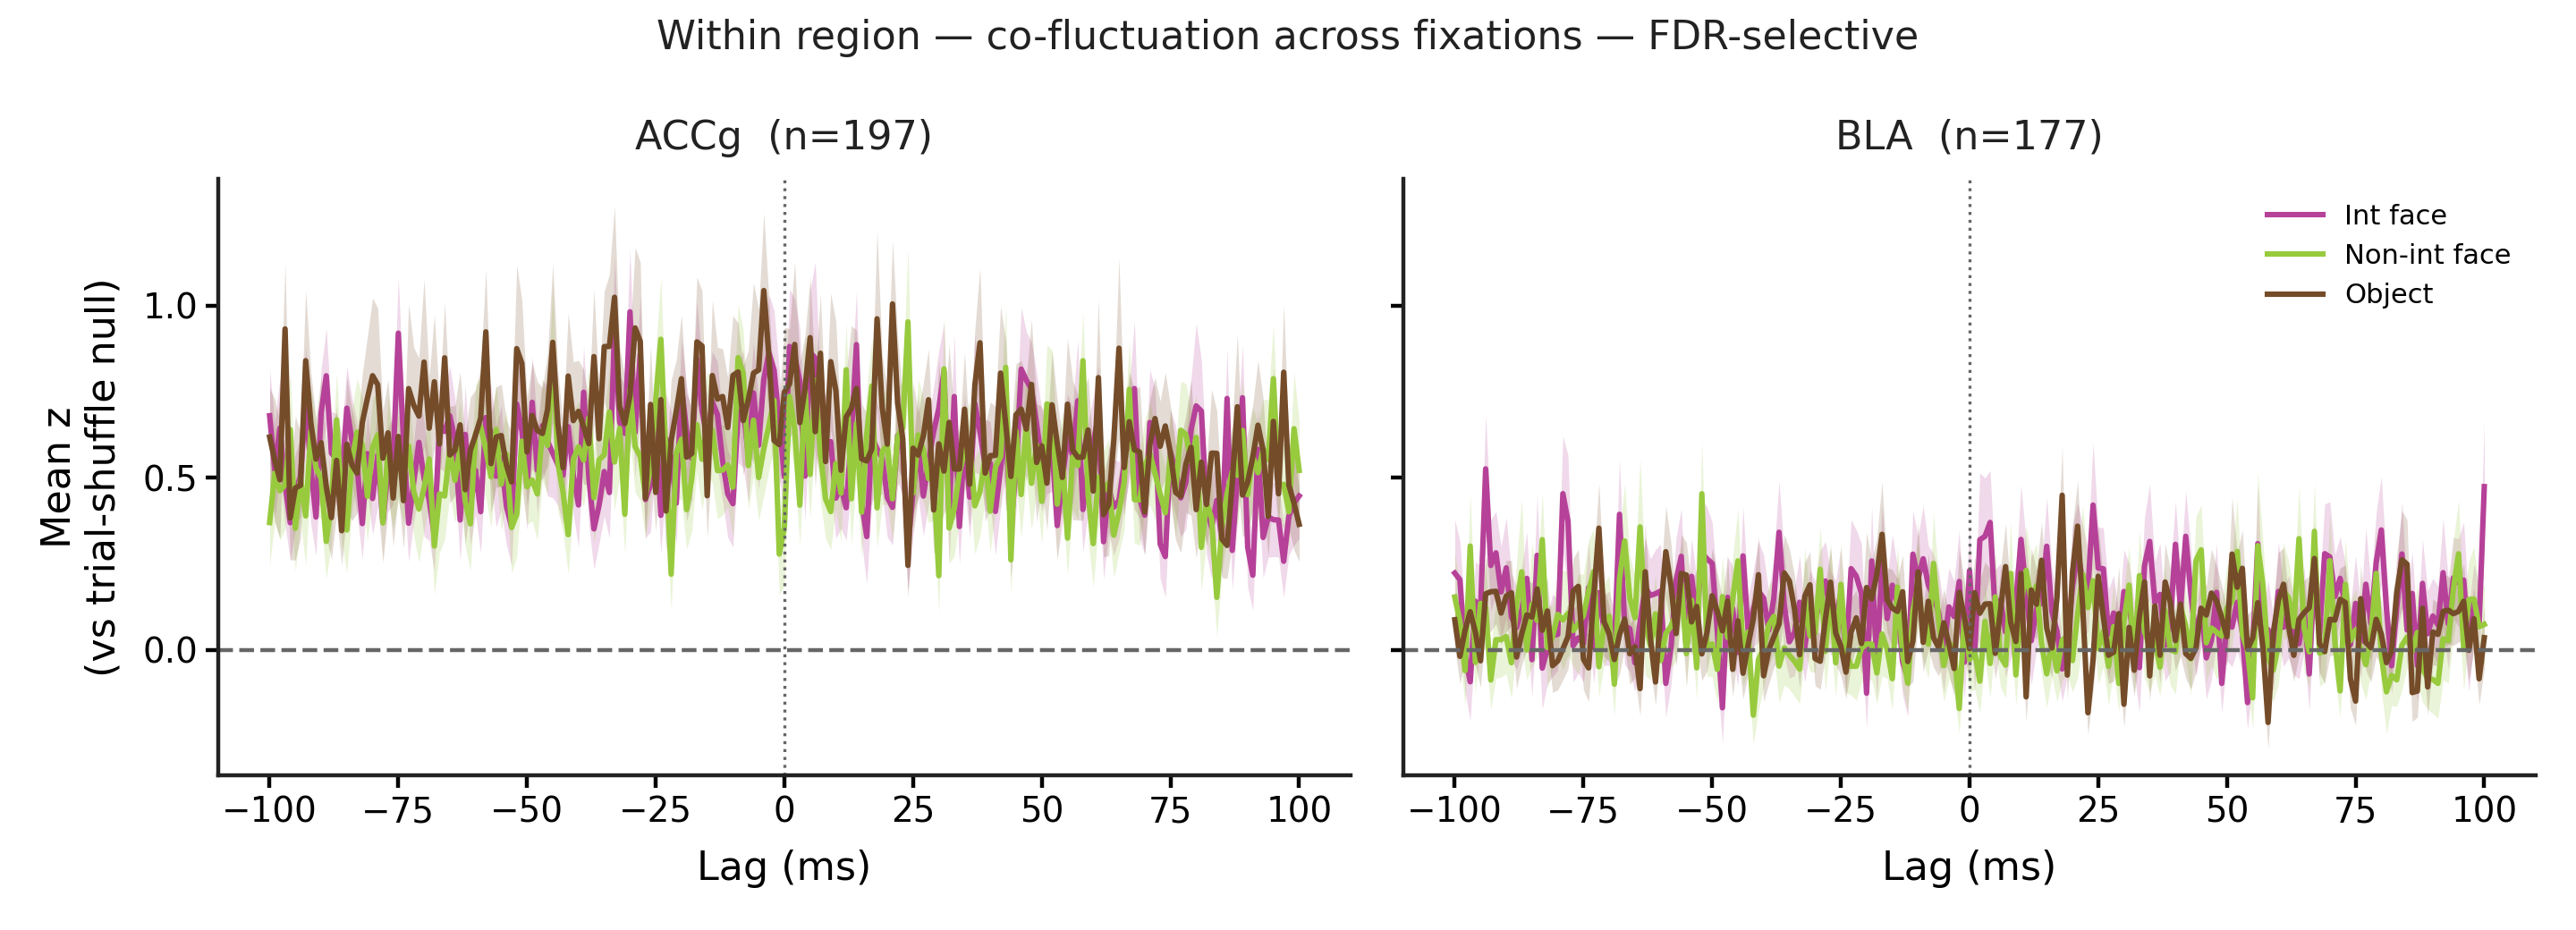

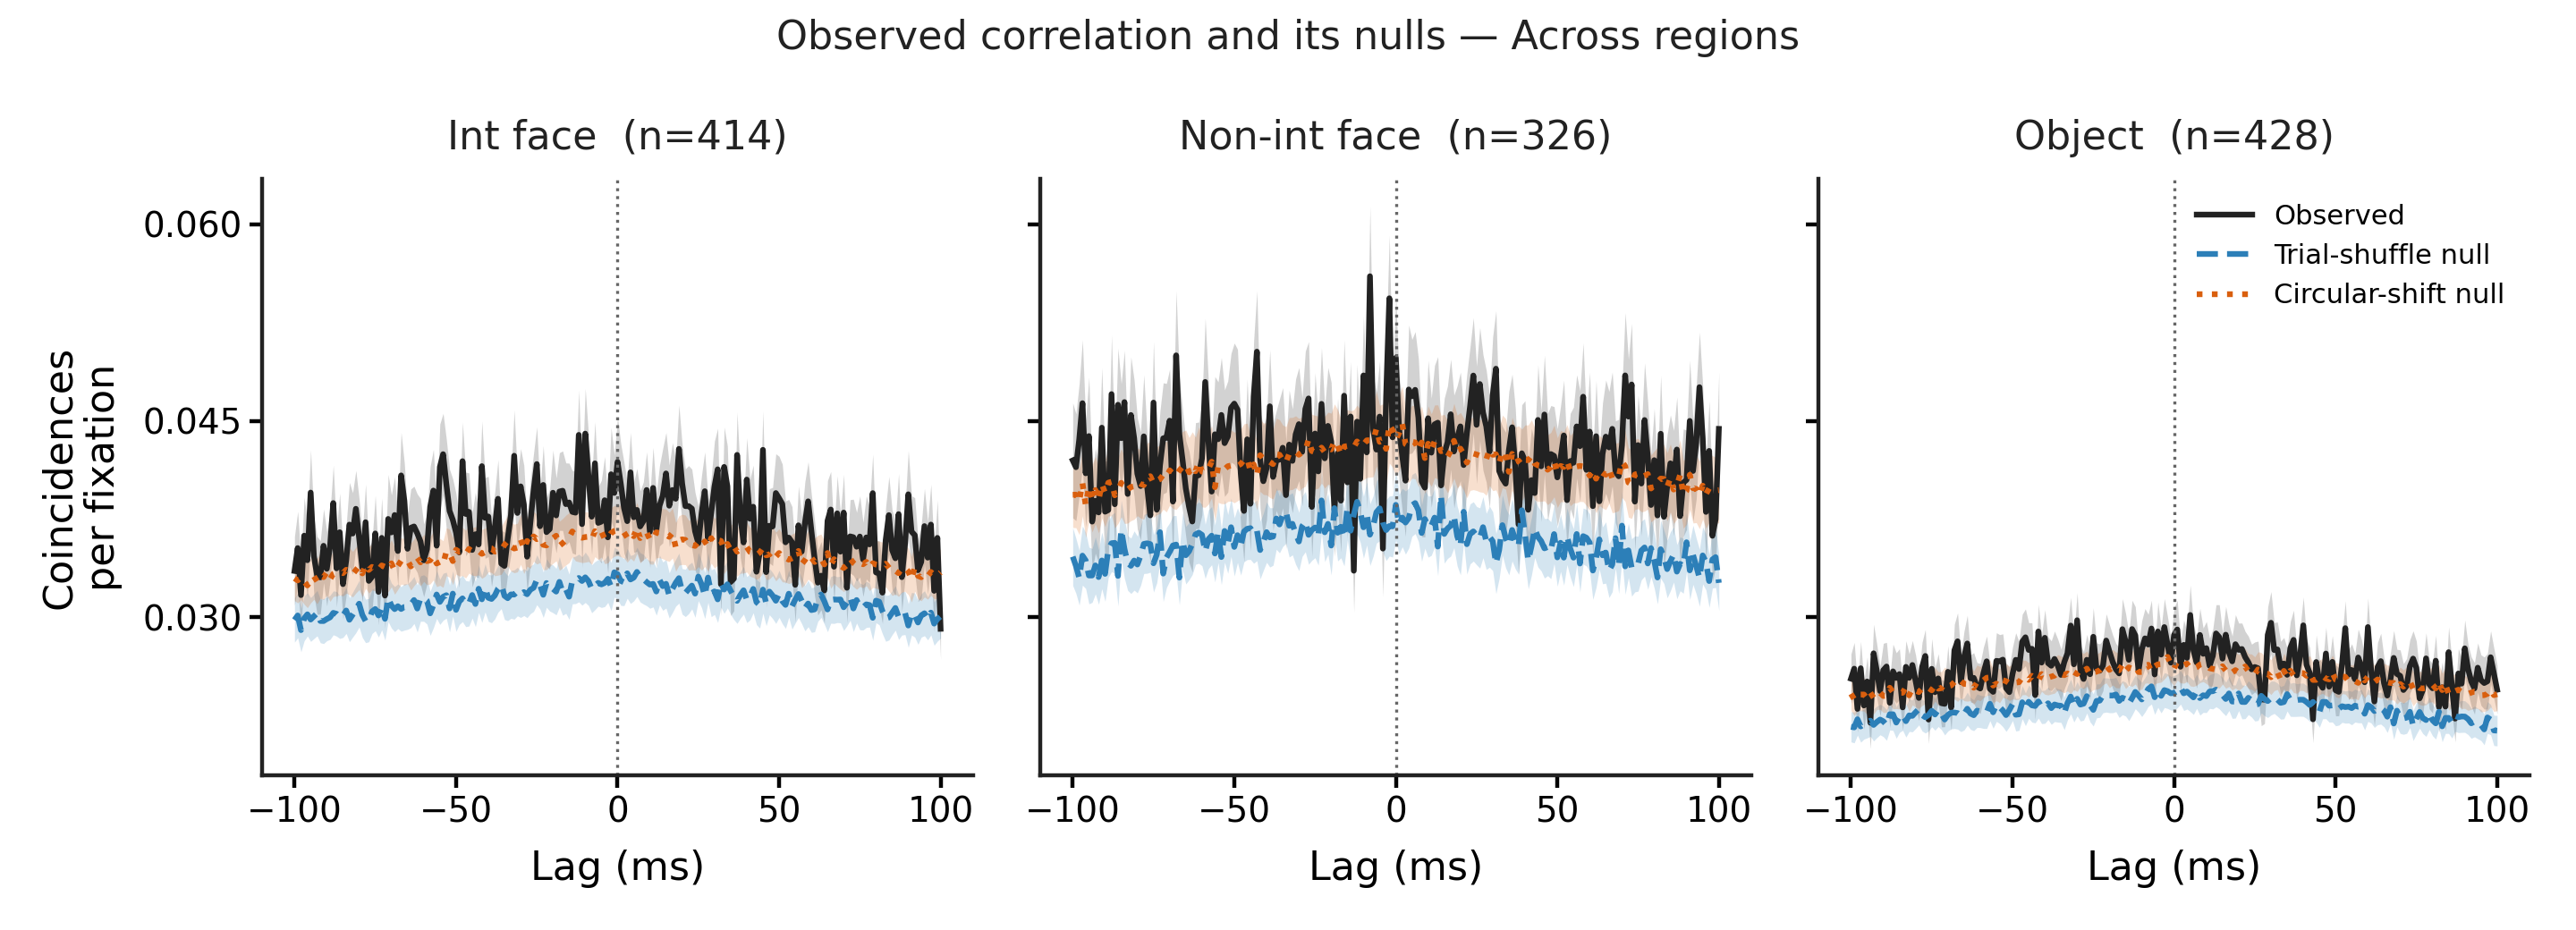

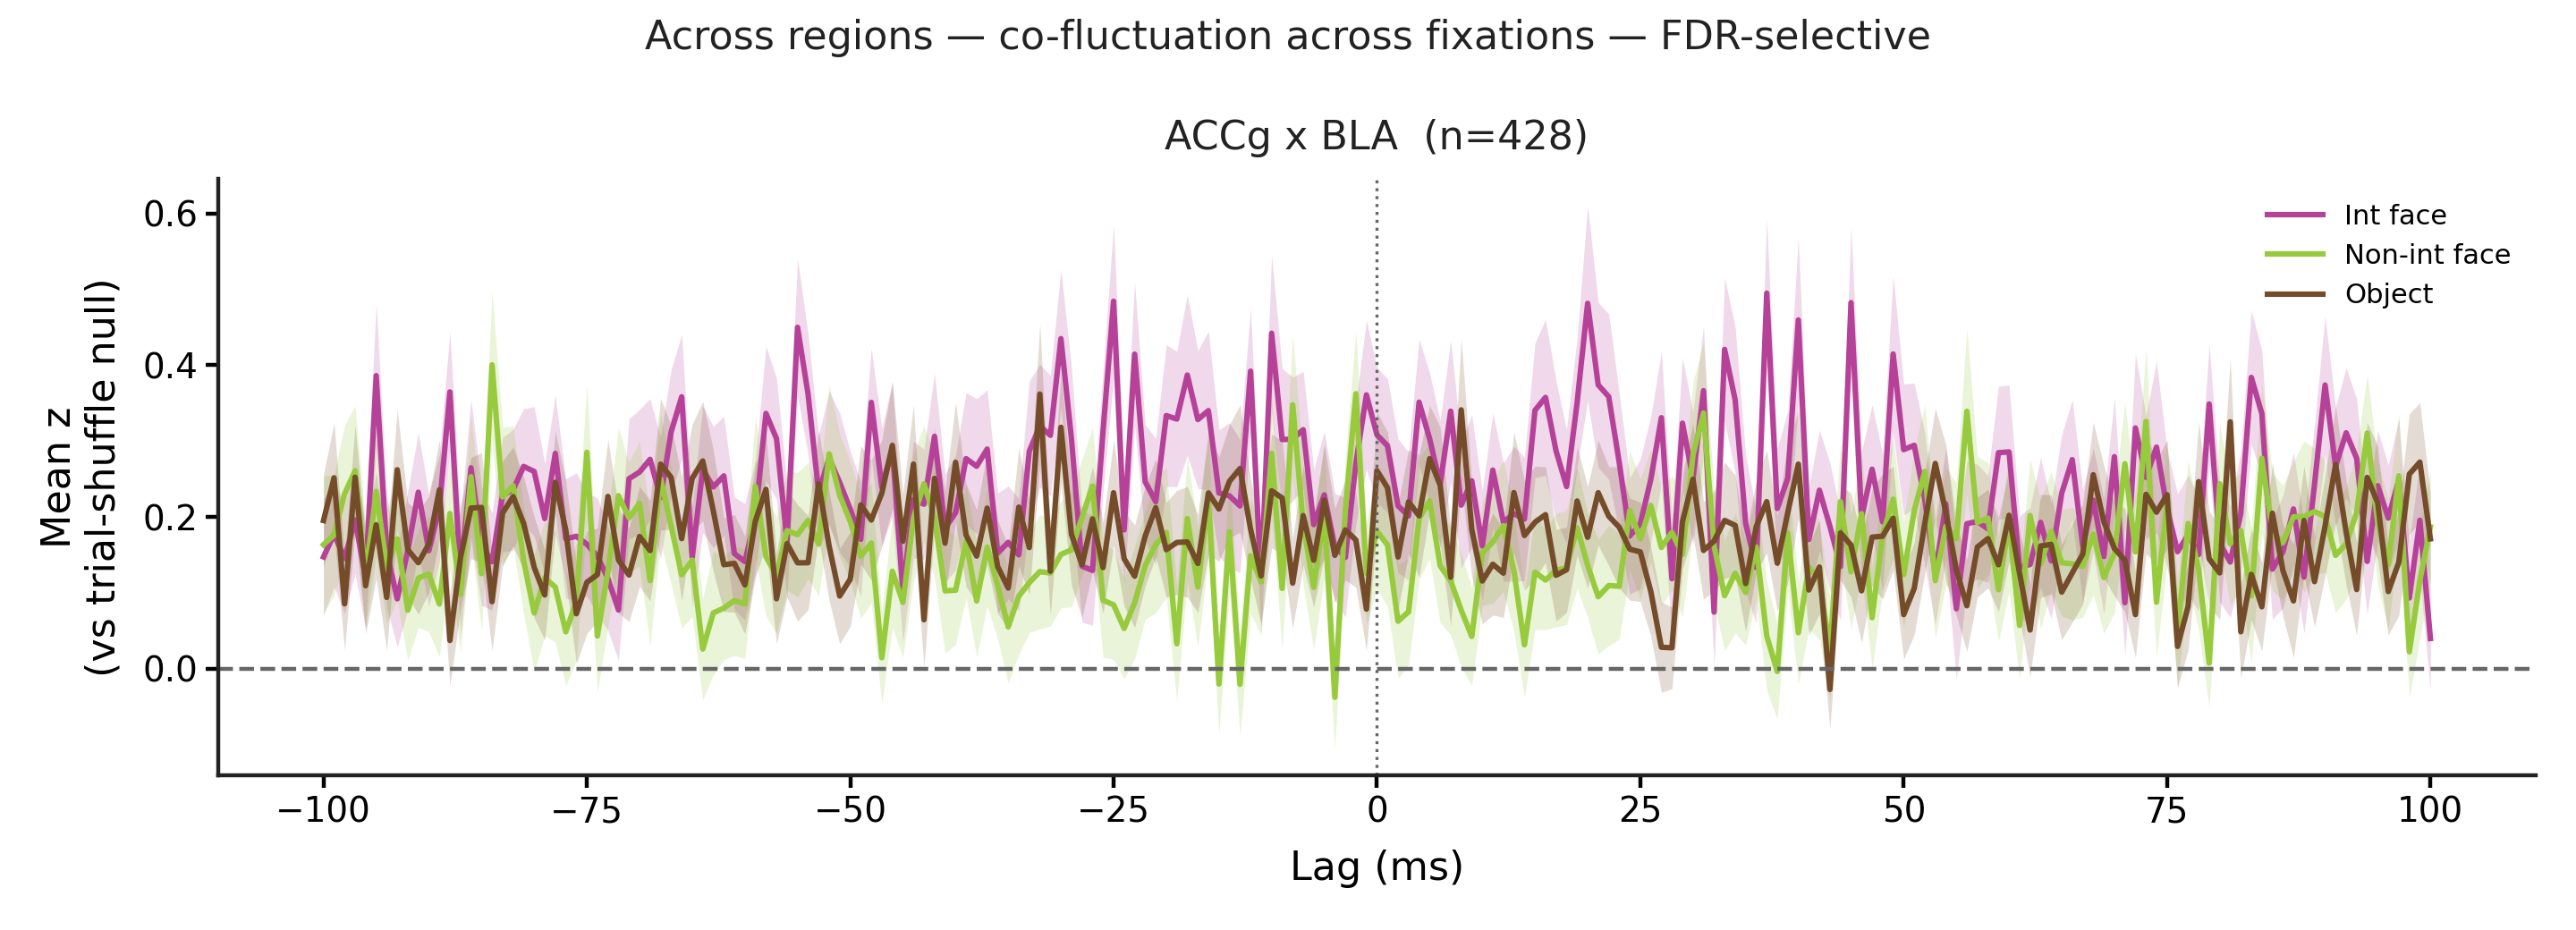

In [12]:
selective = pairs.loc[pairs["both_selective"]]
print(f"pairs with both units FDR-selective: {len(selective):,} of {len(pairs):,} "
      f"({len(selective) / max(len(pairs), 1):.1%})")
display(psc.build_pair_inventory(selective))

sel_by_scope = pd.read_pickle(SUMMARY_DIR / "group_traces_selective.pkl")
sel_by_region = pd.read_pickle(SUMMARY_DIR / "group_traces_by_region_selective.pkl")

for scope in ("within_region", "cross_region"):
    fig, paths = viz.plot_observed_and_nulls(
        sel_by_scope, fig_settings, scope=scope, stem="fig10_observed_and_nulls_selective"
    )
    display(Image(filename=str(paths["png"])))
    fig, paths = viz.plot_region_traces(
        sel_by_region, fig_settings, scope=scope, label="FDR-selective",
        stem="fig11_region_traces_selective",
    )
    display(Image(filename=str(paths["png"])))

### Selective-pair contrasts, against the all-pair result

The final table puts the two side by side on the same rows, so a difference in
conclusion is visible directly rather than inferred by comparing two tables.

,scope,region_pair,condition_a,condition_b,n_pairs,mean_a,mean_b,mean_difference,statistic,p_value,effect_size_rank_biserial,p_value_corrected,significant,pvalue_correction
0,cross_region,accg-bla,face_interactive,face_non_interactive,312,0.0391,0.0384,0.0006,22383.0,0.2028,0.0449,0.2282,False,fdr_bh
1,cross_region,accg-bla,face_interactive,object,400,0.0505,0.0351,0.0154,36218.0,0.0934,0.0550,0.1681,False,fdr_bh
2,cross_region,accg-bla,face_non_interactive,object,326,0.0356,0.0321,0.0035,24762.0,0.2675,-0.0736,0.2675,False,fdr_bh
3,within_region,accg,face_interactive,face_non_interactive,146,0.1084,0.1541,-0.0457,4498.0,0.0901,-0.0548,0.1681,False,fdr_bh
4,within_region,accg,face_interactive,object,183,0.1349,0.1362,-0.0013,7501.0,0.2013,0.0820,0.2282,False,fdr_bh
5,within_region,accg,face_non_interactive,object,146,0.1541,0.1061,0.0480,4188.0,0.0214,0.1233,0.1074,False,fdr_bh
6,within_region,bla,face_interactive,face_non_interactive,121,0.0299,0.0099,0.0200,2817.0,0.0239,0.1570,0.1074,False,fdr_bh
7,within_region,bla,face_interactive,object,159,0.0286,0.0111,0.0175,5285.0,0.0645,0.1195,0.1681,False,fdr_bh
8,within_region,bla,face_non_interactive,object,133,0.0052,0.0138,-0.0087,3821.0,0.1542,-0.1278,0.2282,False,fdr_bh


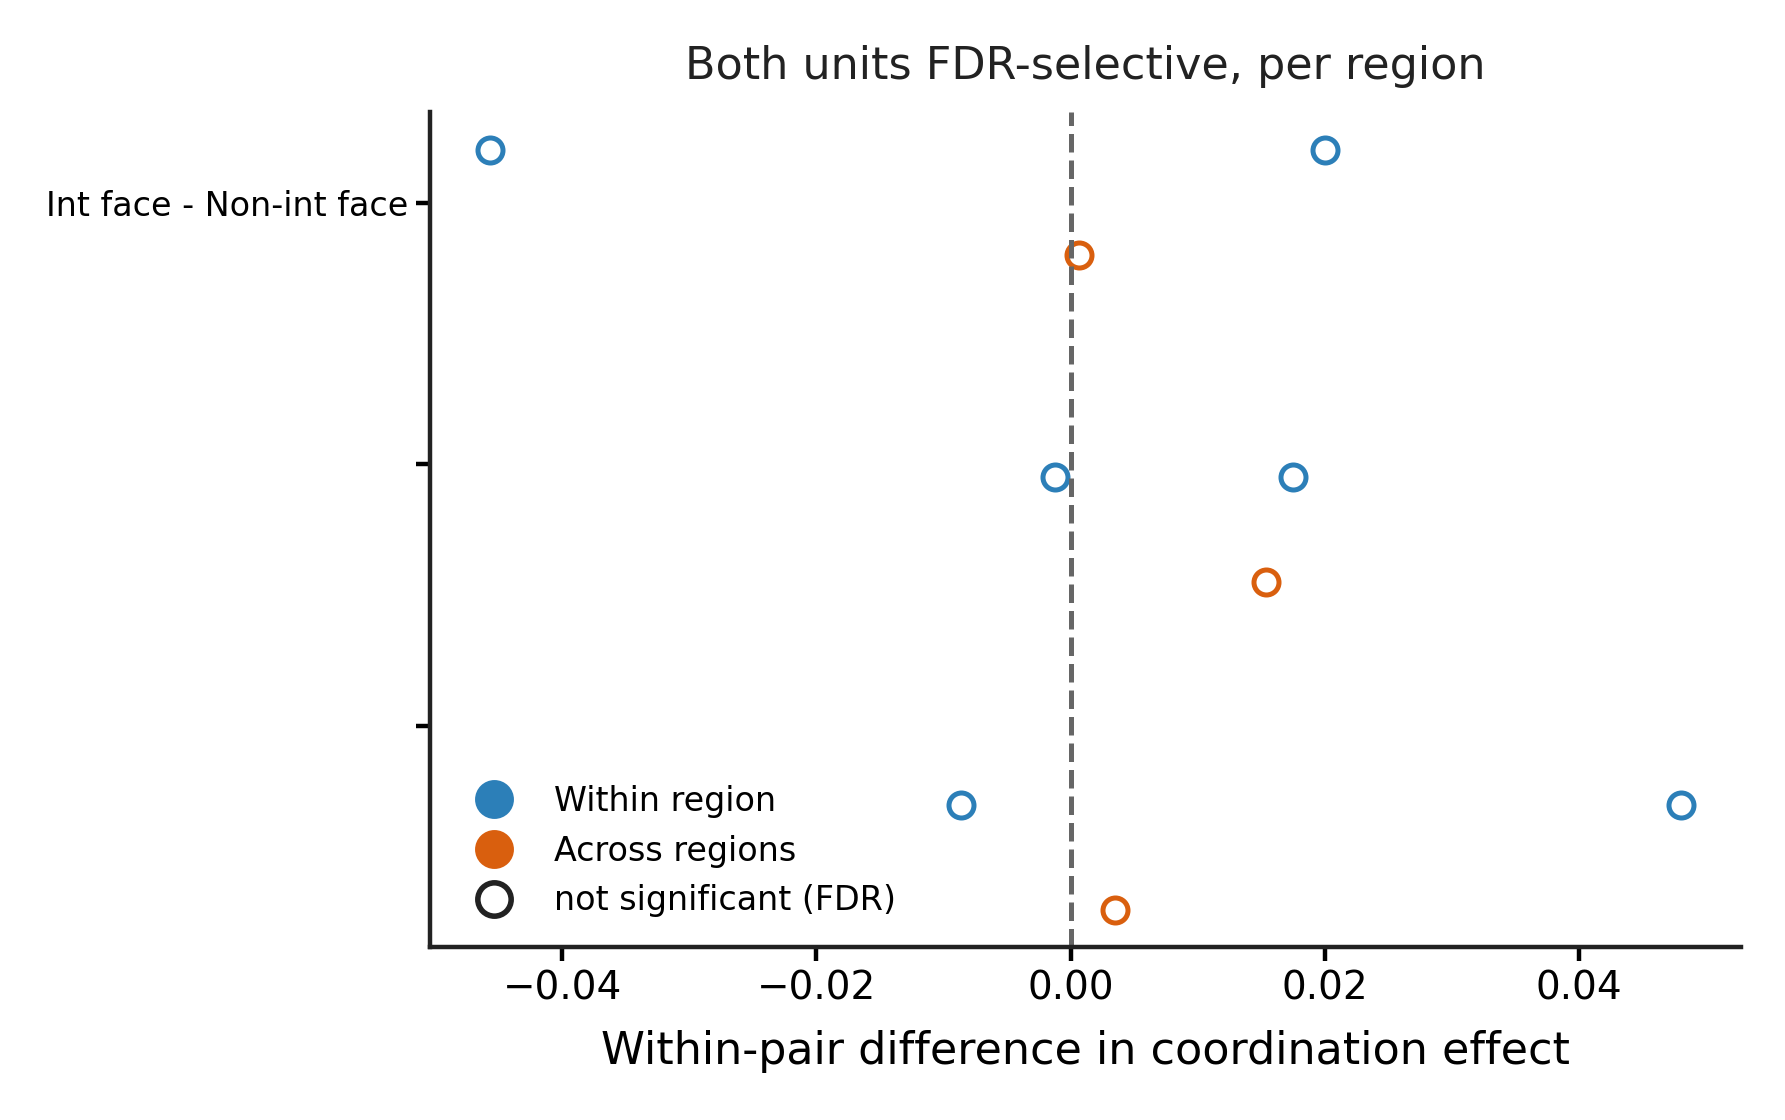

,scope,region_pair,condition_a,condition_b,n_pairs_all,mean_difference_all,significant_all,n_pairs_selective,mean_difference_selective,significant_selective
0,cross_region,accg-bla,face_interactive,face_non_interactive,639,-0.0012,True,312,0.0006,False
1,cross_region,accg-bla,face_interactive,object,844,0.0067,True,400,0.0154,False
2,cross_region,accg-bla,face_non_interactive,object,648,-0.0014,False,326,0.0035,False
3,within_region,accg,face_interactive,face_non_interactive,258,-0.0479,True,146,-0.0457,False
4,within_region,accg,face_interactive,object,316,0.0119,True,183,-0.0013,False
5,within_region,accg,face_non_interactive,object,258,0.0584,True,146,0.0480,False
6,within_region,bla,face_interactive,face_non_interactive,318,0.0023,False,121,0.0200,False
7,within_region,bla,face_interactive,object,455,0.0141,True,159,0.0175,False
8,within_region,bla,face_non_interactive,object,328,-0.0031,False,133,-0.0087,False


In [13]:
sel_contrasts = pd.read_csv(SUMMARY_DIR / "condition_comparisons_by_region_selective.csv")
display(sel_contrasts.round(4))

fig, paths = viz.plot_condition_contrasts(
    sel_contrasts, fig_settings,
    label="Both units FDR-selective, per region", stem="fig12_contrasts_selective",
)
display(Image(filename=str(paths["png"])))

# Side by side with the all-pairs result on the same rows.
side_by_side = by_region_contrasts.merge(
    sel_contrasts, on=["scope", "region_pair", "condition_a", "condition_b"],
    suffixes=("_all", "_selective"),
)
display(
    side_by_side.loc[
        :,
        ["scope", "region_pair", "condition_a", "condition_b",
         "n_pairs_all", "mean_difference_all", "significant_all",
         "n_pairs_selective", "mean_difference_selective", "significant_selective"],
    ].round(4)
)

## 9. The zero-lag artifact

Earlier runs showed a sharp zero-lag peak on some days. That is almost certainly
**not** a pairwise interaction: the chance that two randomly sampled neurons are
monosynaptically connected is near zero, so a zero-lag peak shared by most pairs
on a day is common input — movement, arousal, or a shared reference/ground
artifact.

The signature separating an artifact from a real effect is that it is a property
of the **day and array**, not of the pair: on a contaminated day nearly every
simultaneously recorded pair shows it, including pairs sharing nothing else.

,date,scope,n_pairs,mean_zero_lag_z,median_zero_lag_z,frac_pairs_zero_lag_above,mean_zero_lag_sharpness,suspected_zero_lag_artifact
0,01312018,cross_region,2440,0.1273,-0.2919,0.0373,0.0441,False
1,01312018,within_region,2237,0.0627,-0.3656,0.0443,-0.0501,False


_No date stands out as a zero-lag outlier._

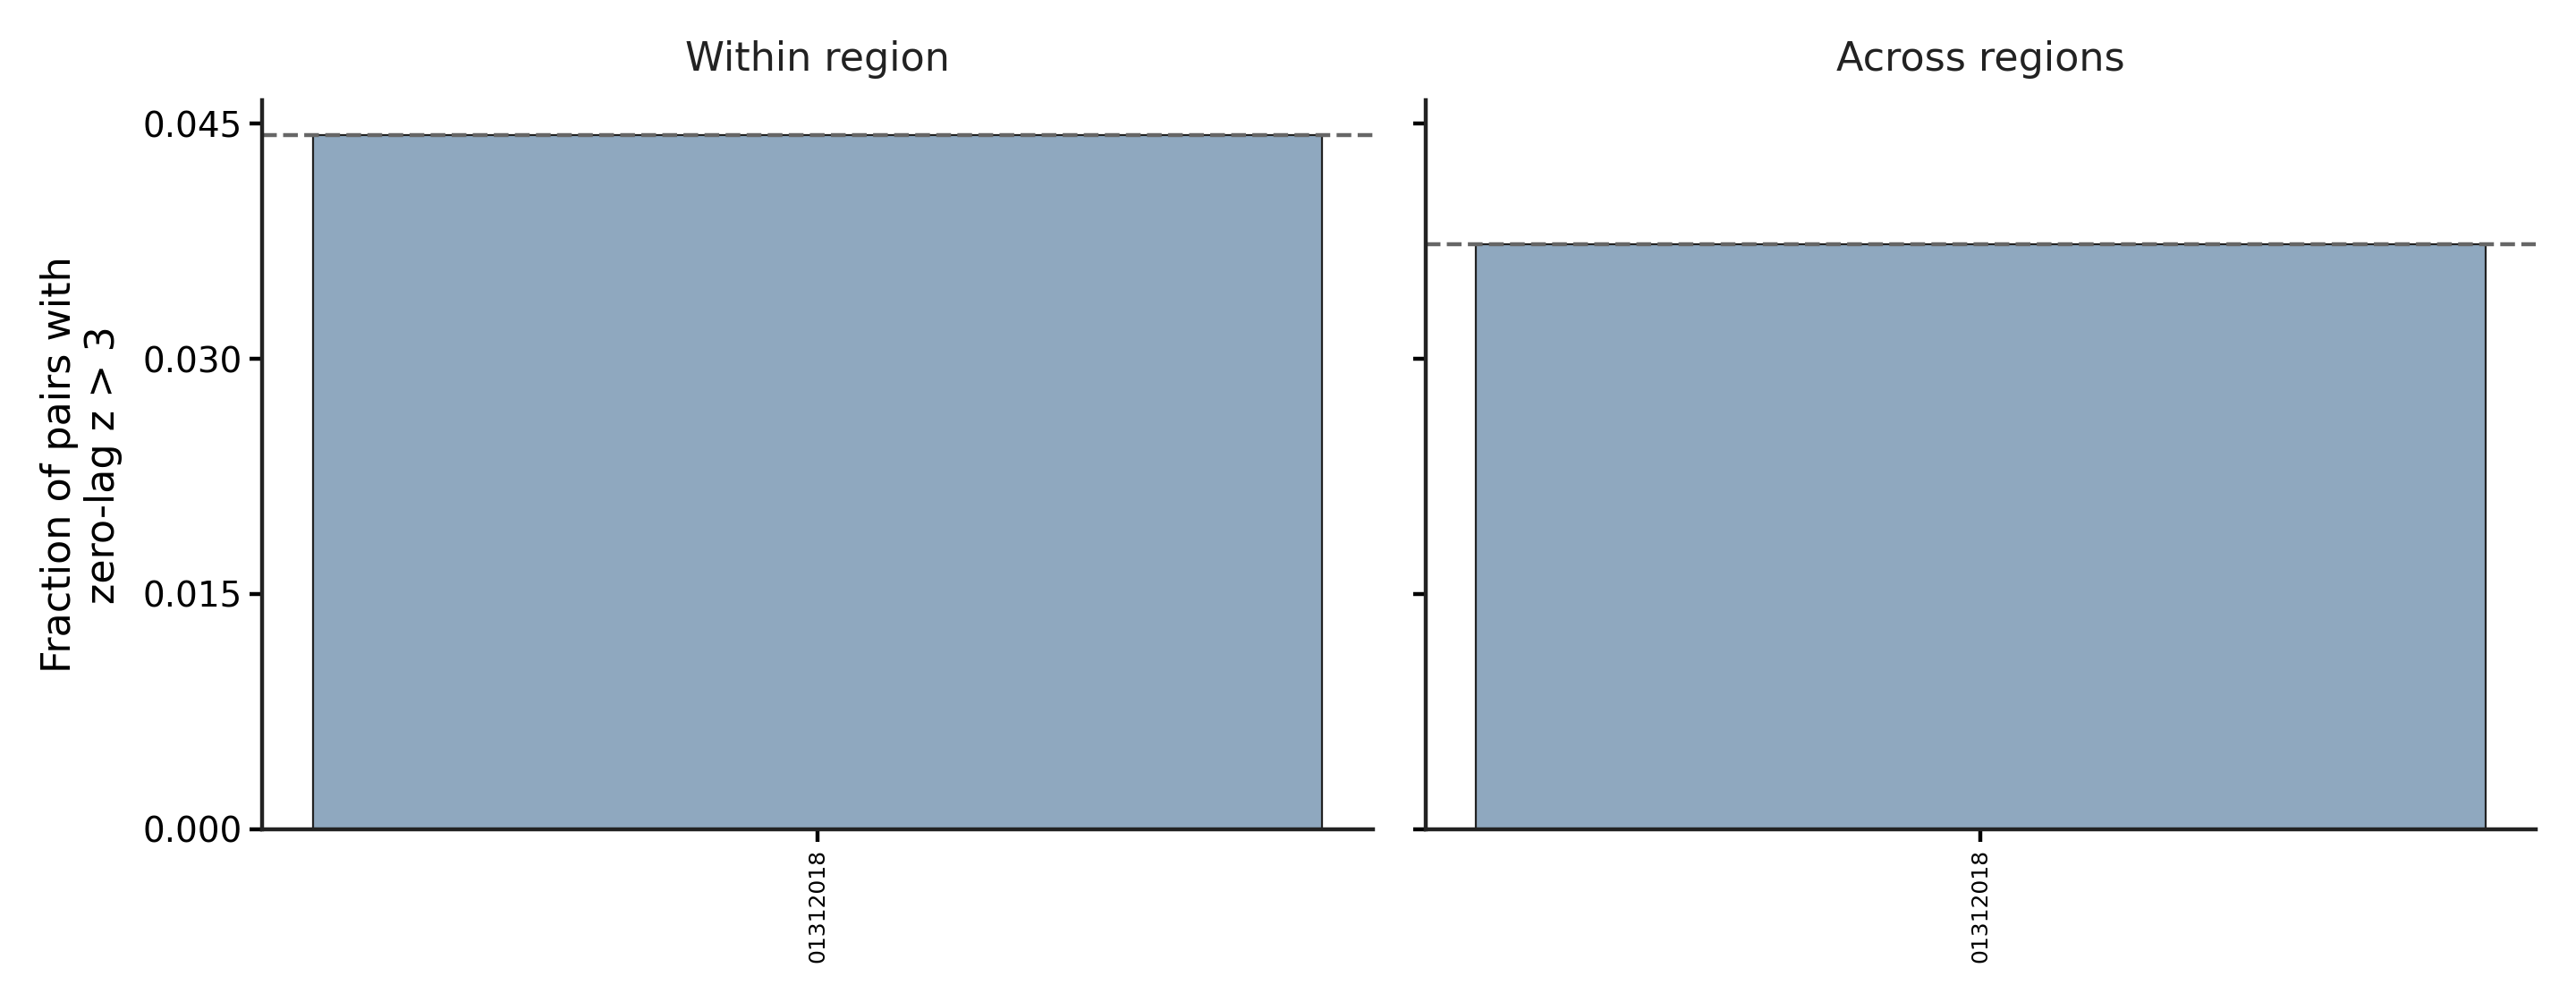

In [14]:
diagnostics = psc.build_zero_lag_diagnostics(pairs)
display(diagnostics.round(4))

flagged = diagnostics.loc[diagnostics["suspected_zero_lag_artifact"].fillna(False)]
if len(flagged):
    display(Markdown(
        f"**{len(flagged)} date/scope combinations flagged.** "
        f"Dates: {sorted(flagged['date'].unique())}"
    ))
else:
    display(Markdown("_No date stands out as a zero-lag outlier._"))

fig, paths = viz.plot_zero_lag_diagnostics(diagnostics, fig_settings)
display(Image(filename=str(paths["png"])))

## 10. Does the conclusion survive dropping flagged days?

The honest test of an artifact: remove the suspect days and see whether the
condition effects hold.

In [15]:
flagged_dates = set(
    psc.build_zero_lag_diagnostics(pairs)
    .pipe(lambda d: d.loc[d["suspected_zero_lag_artifact"].fillna(False), "date"])
    .astype(str)
)
if flagged_dates:
    clean = pairs.loc[~pairs["date"].astype(str).isin(flagged_dates)]
    print(f"dropping {len(flagged_dates)} flagged date(s): {sorted(flagged_dates)}")
    print(f"pairs remaining: {len(clean):,} of {len(pairs):,}")
    clean_comparisons = psc.compare_conditions(
        clean, metric=EFFECT_METRIC, group_columns=("scope", "region_pair")
    )
    display(clean_comparisons.round(4))
    display(Markdown(
        "If the condition effects above match the all-days result, the conclusion "
        "does not rest on the flagged days."
    ))
else:
    display(Markdown("_No days were flagged, so there is nothing to exclude._"))

_No days were flagged, so there is nothing to exclude._